<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module9_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 9: Time Series Forecasting**
---

#### **Module 9.1: Introduction to Time Series and Its Components**

Time series data consists of observations collected sequentially over time, making it distinct from other types of data due to temporal dependencies. Understanding the structure of time series is essential for effective analysis and forecasting.

Key components of time series include:  
- **Trend:** The long-term upward or downward movement in the data.  
- **Seasonality:** Regular, repeating patterns or cycles over fixed periods (e.g., daily, monthly, yearly).  
- **Cycles:** Fluctuations with non-fixed periods, often influenced by economic or business conditions.  
- **Irregular (Noise):** Random, unpredictable variations that cannot be explained by trend or seasonality.

Applications of time series analysis span numerous fields such as engineering (predictive maintenance), finance (stock price forecasting), and operations (demand planning).

This sub-module will build foundational understanding of time series data and its decomposition, preparing you to model and forecast effectively.

---

#### **Exercise 1: Loading and Visualizing Time Series Data**

In this exercise, you will learn how to **load time series data** from a Python library and create a plot to inspect patterns. This step allows you to quickly spot **trends**, **seasonality**, and **outliers** before applying formal time series methods.

You will:
- Load the `"flights"` dataset from the `seaborn` library.
- Convert year and month columns into a single `DatetimeIndex`.
- Plot the series to visualize overall patterns.
- Format the plot with labels, title, and grid lines.

---

In [1]:
# Exercise 1: Loading and Visualizing Time Series Data (Seaborn Flights Dataset)
# -------------------------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the flights dataset from seaborn
flights = sns.load_dataset("flights")
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [2]:
# Step 2: Build a proper datetime index
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"  # month is like "Jan", "Feb", ...
)


In [3]:
# Step 3: Set datetime as index
flights.set_index("date", inplace=True)


In [4]:
# Step 4: Optional rename for clarity
flights.rename(columns={"passengers": "Passengers"}, inplace=True)

# Step 5: Inspect dataset
print("Dataset head:")
print(flights.head())
print("\nDataset info:")
print(flights.info())

Dataset head:
            year month  Passengers
date                              
1949-01-01  1949   Jan         112
1949-02-01  1949   Feb         118
1949-03-01  1949   Mar         132
1949-04-01  1949   Apr         129
1949-05-01  1949   May         121

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   Passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 3.9 KB
None


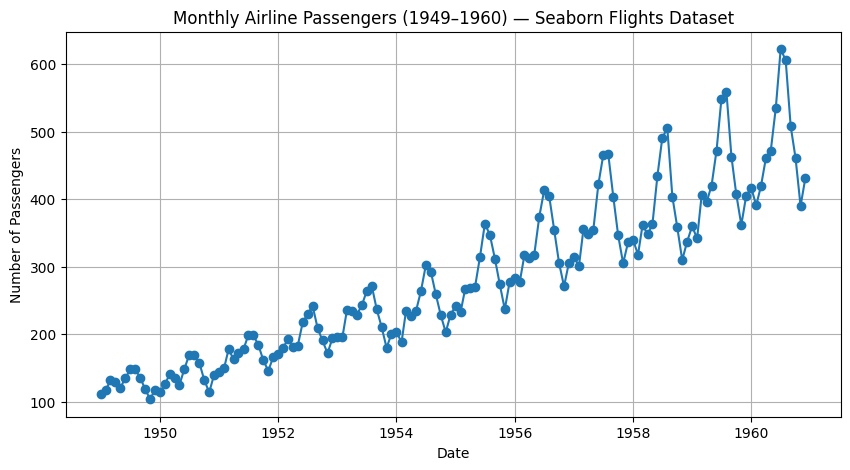

In [5]:
# Step 6: Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(flights.index, flights["Passengers"], marker="o", linestyle="-")
plt.title("Monthly Airline Passengers (1949–1960) — Seaborn Flights Dataset")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise began with loading the flights dataset and examining its structure to understand how time-based data is organized. The year and month columns were then combined into a proper datetime format, making the dataset suitable for time series analysis. Setting the datetime column as the index was an important step, as it enables easier manipulation and visualization of temporal data. After preparing the dataset, a line plot was created to visualize the data over time. The visualization clearly showed an upward trend in the number of passengers along with repeating seasonal patterns each year. These observations helped illustrate how trend and seasonality appear in real-world time series data. Overall, the exercise emphasized the importance of proper data preparation and visualization before moving on to more advanced forecasting methods.


#### **Exercise 2: Identifying Time Series Components**

In this exercise, you will visually inspect a time series to identify its **trend**, **seasonality**, and **irregular (noise)** components. By observing the plot, you can start hypothesizing about the underlying structure before applying formal decomposition.

You will:
- Use the `"flights"` dataset from Seaborn (prepared in Exercise 1).
- Plot the time series and annotate where trend, seasonality, and irregular variations appear.
- Create separate plots to highlight the long-term trend and repeating seasonal patterns.

---

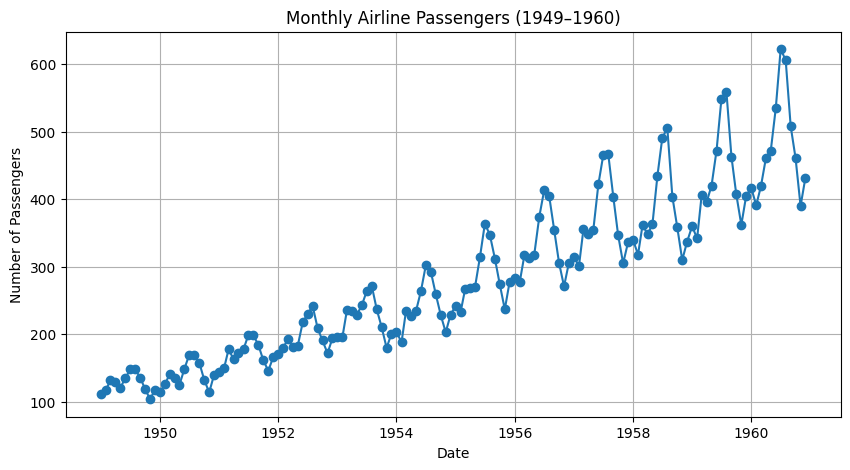

In [6]:
# Exercise 2: Identifying Time Series Components
# ----------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and prepare dataset (same as Exercise 1)
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)
flights.set_index("date", inplace=True)
flights.rename(columns={"passengers": "Passengers"}, inplace=True)

# Step 2: Plot the full time series
plt.figure(figsize=(10, 5))
plt.plot(flights.index, flights["Passengers"], marker="o", linestyle="-")
plt.title("Monthly Airline Passengers (1949–1960)")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

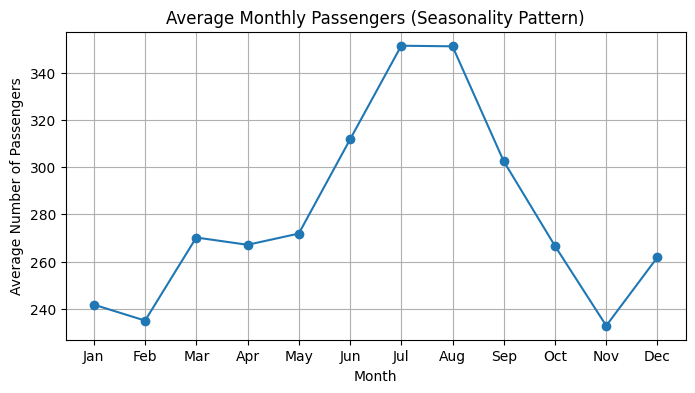

In [7]:
# Step 3: Highlight annual seasonality by grouping by month
monthly_avg = flights.groupby(flights.index.month)["Passengers"].mean()
plt.figure(figsize=(8, 4))
plt.plot(range(1, 13), monthly_avg, marker="o")
plt.xticks(range(1, 13),
           ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("Average Monthly Passengers (Seasonality Pattern)")
plt.xlabel("Month")
plt.ylabel("Average Number of Passengers")
plt.grid(True)
plt.show()


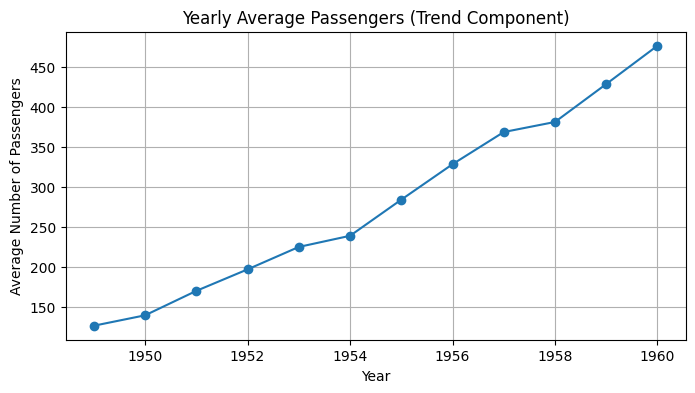

In [8]:
# Step 4: Highlight long-term yearly trend
yearly_avg = flights.groupby(flights.index.year)["Passengers"].mean()
plt.figure(figsize=(8, 4))
plt.plot(yearly_avg.index, yearly_avg, marker="o")
plt.title("Yearly Average Passengers (Trend Component)")
plt.xlabel("Year")
plt.ylabel("Average Number of Passengers")
plt.grid(True)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding the main components of a time series by working with the flights dataset. The data was first prepared by converting the year and month into a datetime format and setting it as the index, which made it easier to analyze over time. A line plot of the full dataset helped reveal the overall pattern, where a steady increase in passengers over the years indicated a clear trend. To better understand seasonality, the data was grouped by month, and the average values showed repeating patterns across the same months each year. The yearly averages were also plotted to clearly highlight the long-term upward trend. Small fluctuations around these patterns represented irregular or random variations in the data. Overall, this exercise helped build a clearer understanding of how trend, seasonality, and noise appear and can be visually identified in time series data.


#### **Exercise 3: Time Series Decomposition**

In this exercise, you will decompose a time series into its **trend**, **seasonal**, and **residual** (irregular) components using the **seasonal_decompose** function from `statsmodels`.  
This method allows you to clearly separate and analyze each component for better understanding and modeling.

You will:
- Use the `"flights"` dataset prepared earlier.
- Apply an **additive decomposition** to break the series into components.
- Visualize the decomposed components to interpret patterns.

---

In [9]:
# Exercise 3: Time Series Decomposition
# -------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Load and prepare dataset (same as previous exercises)
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)
flights.set_index("date", inplace=True)
flights.rename(columns={"passengers": "Passengers"}, inplace=True)


In [10]:
# Step 2: Apply additive decomposition
decomposition = seasonal_decompose(flights["Passengers"], model="additive", period=12)


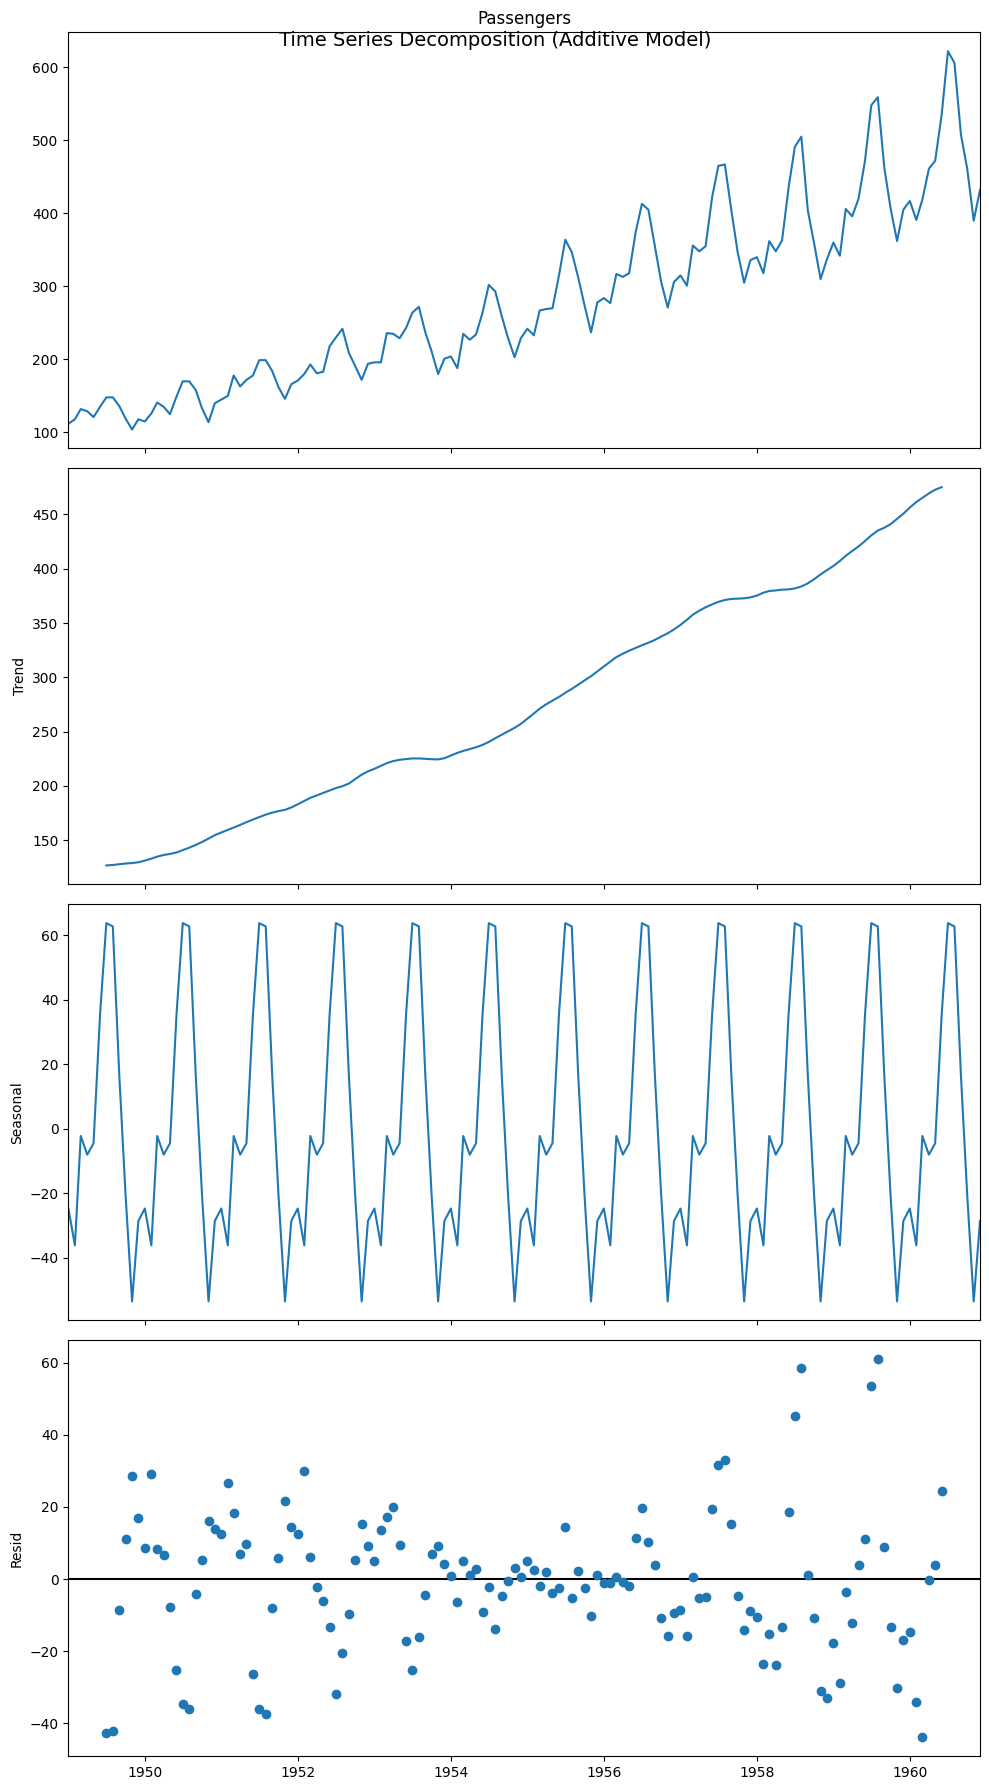

In [69]:
# Step 3: Plot decomposed components
plt.rcParams.update({'figure.figsize': (10, 18)})
decomposition.plot()
plt.suptitle("Time Series Decomposition (Additive Model)", fontsize=14)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on breaking down the time series into its main components to better understand its structure. The dataset was first prepared in the same way as before by creating a datetime index, which ensures the data is properly aligned over time. Then, an additive decomposition method was applied to separate the series into trend, seasonal, and residual components. The trend component clearly showed the overall increase in passenger numbers over the years. The seasonal component highlighted repeating patterns within each year, showing how certain months consistently have higher or lower values. The residual component captured the random fluctuations that are not explained by trend or seasonality. Overall, this exercise made it easier to see how each part contributes to the overall time series and why decomposition is useful before building forecasting models.


#### **Exercise 4: Comparing Additive and Multiplicative Decomposition Models**

In this exercise, you will compare **additive** and **multiplicative** decomposition models for the same time series to understand when each is appropriate.

- **Additive model:**  
  Assumes that the time series is the sum of its components:  


  $ Y_t = T_t + S_t + R_t $

  
  Works best when seasonal variations are roughly constant over time.

- **Multiplicative model:**  
  Assumes that the time series is the product of its components:  


  $ Y_t = T_t \times S_t \times R_t $

  
  Works best when seasonal variations change proportionally with the trend.

You will:
- Use the `"flights"` dataset prepared earlier.
- Apply both additive and multiplicative decompositions.
- Visually compare the seasonal components to see the difference.

---

In [12]:
# Exercise 4: Comparing Additive and Multiplicative Decomposition Models
# ----------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Load and prepare dataset
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)
flights.set_index("date", inplace=True)
flights.rename(columns={"passengers": "Passengers"}, inplace=True)


In [13]:
# Step 2: Additive decomposition
add_decomp = seasonal_decompose(flights["Passengers"], model="additive", period=12)


In [14]:
# Step 3: Multiplicative decomposition
mult_decomp = seasonal_decompose(flights["Passengers"], model="multiplicative", period=12)


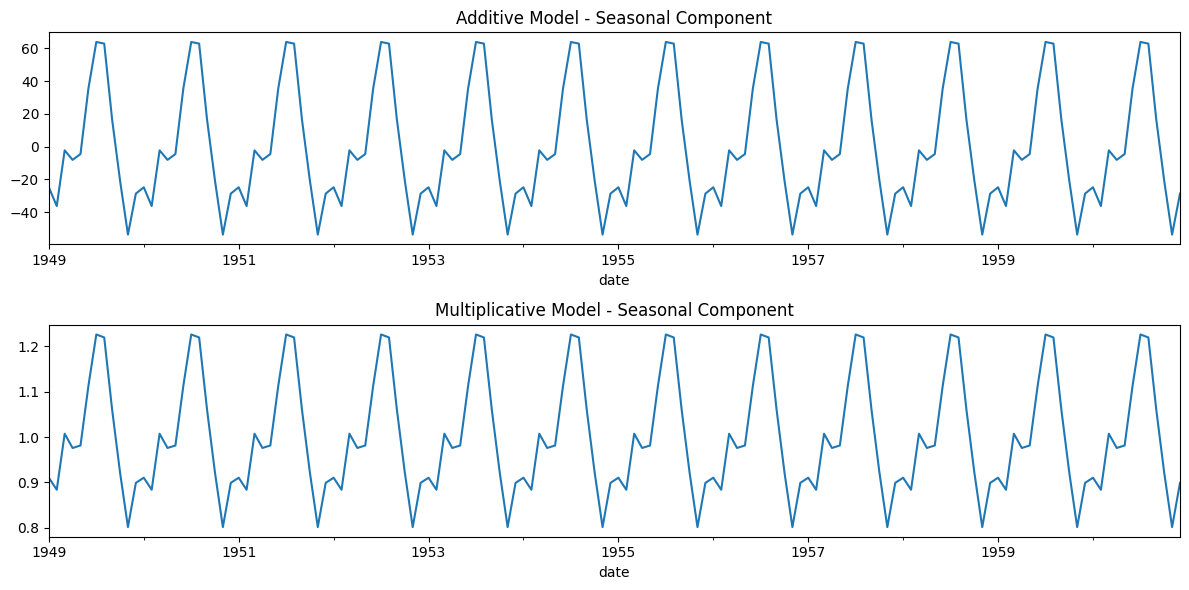

In [15]:
# Step 4: Plot comparison of seasonal components
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
add_decomp.seasonal.plot(ax=plt.gca())
plt.title("Additive Model - Seasonal Component")

plt.subplot(2, 1, 2)
mult_decomp.seasonal.plot(ax=plt.gca())
plt.title("Multiplicative Model - Seasonal Component")

plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on comparing additive and multiplicative decomposition models to understand how they handle seasonality differently. The dataset was first prepared by converting the date information into a proper datetime index, making it ready for time series analysis. Both additive and multiplicative decompositions were then applied to the same data. The seasonal components from each model were plotted to visually compare how they behave. The additive model showed seasonal patterns that stay relatively constant over time, while the multiplicative model showed patterns that increase as the overall trend increases. This made it clear that multiplicative models are more suitable when seasonal effects grow with the data. Overall, the exercise helped build a better understanding of when to use each type of decomposition model based on the nature of the data.


#### **Module 9.2: Stationarity, Transformations, and Autocorrelation Analysis**

Stationarity is a key concept in time series analysis referring to the property that statistical characteristics such as mean, variance, and autocorrelation remain constant over time. Many forecasting models assume stationarity for accurate predictions.

In this sub-module, you will learn how to:  
- Identify **stationarity** through visual inspection and statistical tests like the Augmented Dickey-Fuller (ADF) test.  
- Apply **transformations** such as logarithms or square roots to stabilize variance.  
- Use **differencing** techniques to remove trends and achieve stationarity by subtracting previous observations.  
- Analyze **autocorrelation** (ACF) and **partial autocorrelation** (PACF) plots to detect time dependencies and inform model selection.

Mastering these concepts is essential for preparing time series data for modeling and ensuring valid, reliable forecasts.

---

#### **Exercise 5: Visual Inspection of Stationarity**

**Objective:**  
Learn how to visually inspect a time series to determine whether it appears stationary, by plotting the raw series and its rolling statistics (mean and standard deviation). This step helps identify trends, seasonality, and changes in variability over time.

---


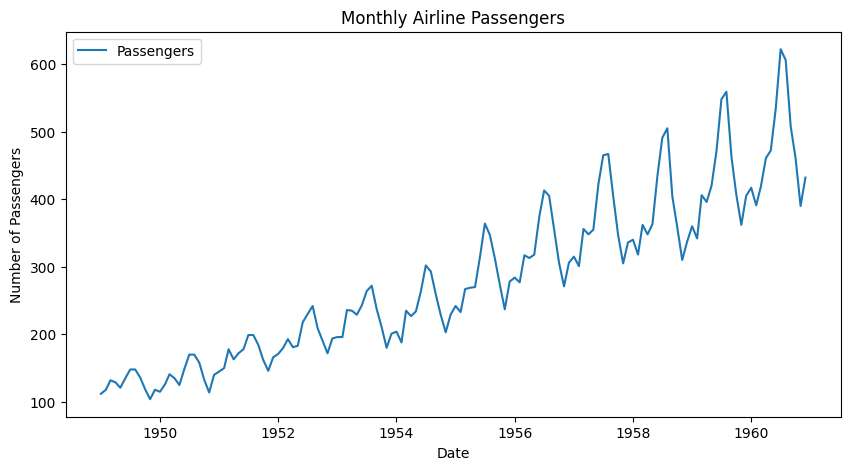

In [16]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load a sample time series dataset
flights = sns.load_dataset("flights")

# Convert month to datetime
flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str) + '-01')
flights.set_index('date', inplace=True)

# Step 3: Plot the raw time series
plt.figure(figsize=(10,5))
plt.plot(flights['passengers'], label='Passengers')
plt.title('Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()


In [17]:
# Step 4: Calculate rolling mean and standard deviation
rolling_mean = flights['passengers'].rolling(window=12).mean()
rolling_std = flights['passengers'].rolling(window=12).std()


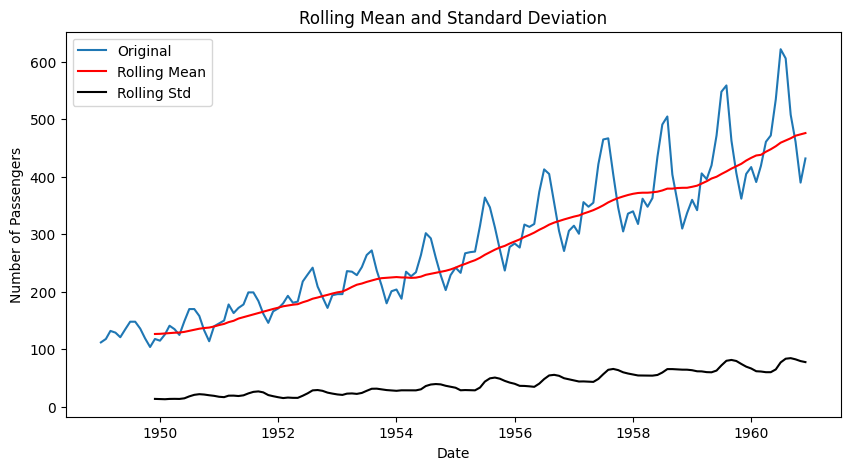

In [18]:
# Step 5: Plot rolling statistics
plt.figure(figsize=(10,5))
plt.plot(flights['passengers'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std')
plt.title('Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding stationarity by visually inspecting the time series data. The dataset was first loaded and converted into a proper datetime format so it could be analyzed over time. Then, the raw time series of airline passengers was plotted to observe general patterns like trend and fluctuations. After that, rolling mean and rolling standard deviation were calculated to study how the average and variability change over time. These rolling statistics were plotted along with the original data to make comparisons easier. It was observed that both the mean and standard deviation change over time, which indicates that the series is not stationary. Overall, this exercise helped build an intuitive understanding of stationarity and why it is important before applying forecasting models.

#### **Exercise 6: Augmented Dickey-Fuller (ADF) Test for Stationarity**

**Objective:**  
Learn how to use the **Augmented Dickey-Fuller (ADF) test** to statistically assess whether a time series is stationary.

---

#### **Instructions:**

1. **Load Dataset**  
   Use the **flights** dataset from Seaborn.

2. **Preprocess Data**  
   - Convert `year` and `month` into a datetime column.
   - Set the datetime column as the index.

3. **Visual Inspection**  
   Plot the time series to observe any visible trends or seasonality.

4. **Apply ADF Test**  
   - Use `adfuller()` from `statsmodels.tsa.stattools` on the passenger count series.
   - Record the ADF statistic, p-value, and critical values.

5. **Interpret Results**  
   - If p-value < 0.05, reject the null hypothesis (series is stationary).
   - If p-value ≥ 0.05, fail to reject the null hypothesis (series is non-stationary).

6. **Conclusion**  
   Briefly explain whether the series is stationary and why, based on the test results.

---


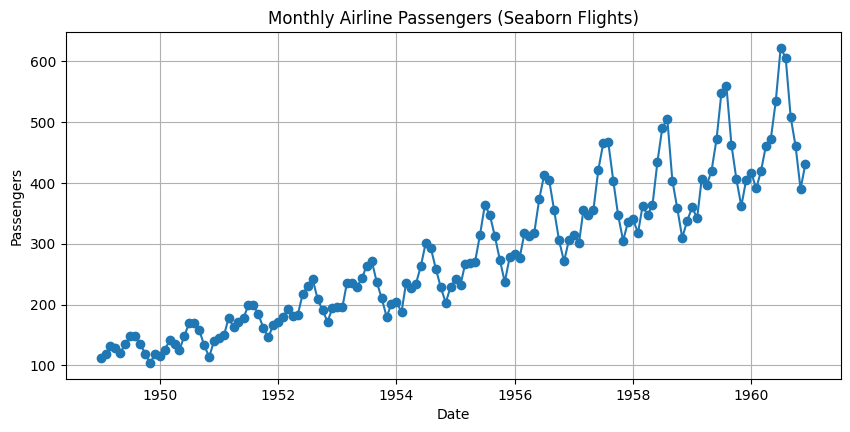

In [19]:
# Exercise 6: Augmented Dickey-Fuller (ADF) Test for Stationarity
# ---------------------------------------------------------------
# Goal: Load the flights dataset, visualize it, run the ADF test, and interpret the result.

# Step 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Step 2: Load and preprocess the dataset
flights = sns.load_dataset("flights")

# Build a proper datetime index from year + month (month is categorical like 'Jan', 'Feb', ...)
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)

# Set datetime index and keep only the target series
flights = flights.set_index("date").rename(columns={"passengers": "Passengers"})
series = flights["Passengers"].asfreq("MS")  # ensure monthly start frequency

# Step 3: Visual inspection (plot the raw series)
plt.figure(figsize=(10, 4.5))
plt.plot(series.index, series.values, marker="o", linestyle="-")
plt.title("Monthly Airline Passengers (Seaborn Flights)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()


In [20]:
# Step 4: Run the Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(series.dropna(), autolag="AIC")

# Step 5: Print results neatly
labels = ["ADF Statistic", "p-value", "# Lags Used", "# Observations Used"]
for label, value in zip(labels, adf_result[:4]):
    print(f"{label:>20}: {value}")

print("\nCritical Values:")
for k, v in adf_result[4].items():
    print(f"{k:>20}: {v}")

# Step 6: Simple interpretation helper
pval = adf_result[1]
if pval < 0.05:
    print("\nConclusion: p-value < 0.05 → Reject H0. The series is likely STATIONARY.")
else:
    print("\nConclusion: p-value ≥ 0.05 → Fail to reject H0. The series is likely NON‑STATIONARY.")

       ADF Statistic: 0.8153688792060498
             p-value: 0.991880243437641
         # Lags Used: 13
 # Observations Used: 130

Critical Values:
                  1%: -3.4816817173418295
                  5%: -2.8840418343195267
                 10%: -2.578770059171598

Conclusion: p-value ≥ 0.05 → Fail to reject H0. The series is likely NON‑STATIONARY.


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on using the Augmented Dickey-Fuller (ADF) test to check whether the time series is stationary. The dataset was first loaded and converted into a proper datetime index to make it suitable for time series analysis. Then, the passenger data was plotted to visually inspect trends and seasonality in the series. After that, the ADF test was applied to statistically evaluate stationarity using the p-value and test statistics. The results showed a high p-value, which means the null hypothesis could not be rejected. This indicates that the series is non-stationary and contains trends over time. Overall, the exercise helped connect visual patterns with statistical testing and showed how to confirm stationarity using the ADF test.


#### **Exercise 6: Applying Transformations to Stabilize Variance**

**Objective:**  
Learn how to apply mathematical transformations to a time series to stabilize its variance, which is a crucial step before performing differencing or advanced modeling.

**Background:**  
Many time series exhibit **heteroscedasticity**, where the variability in the data changes over time. This can make it harder for models to capture patterns accurately. Applying transformations such as the **logarithm** or **square root** can reduce large fluctuations and make the variance more consistent across time.

In this exercise, you will:  
1. Load the **Flights dataset** and prepare it for analysis.  
2. Apply a **log transformation** to stabilize variance.  
3. Apply a **square root transformation** as an alternative.  
4. Compare the transformed series visually with the original to observe how variability changes.  

By the end, you’ll understand how transformations help create a more stable foundation for modeling.

---

In [21]:
# Exercise 6: Applying Transformations to Stabilize Variance
# ----------------------------------------------------------
# Goal: Apply log and square-root transformations to the Seaborn flights dataset
#       and visually/quantitatively compare variance stability.

# Step 1: Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load and prepare the dataset
flights = sns.load_dataset("flights")

# Build a proper datetime index from year + month (month is like 'Jan', 'Feb', ...)
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)

# Keep only the target series with a monthly frequency
series = (
    flights.set_index("date")["passengers"]
    .asfreq("MS")  # Monthly Start
    .rename("Passengers")
)


In [22]:
# Step 3: Apply transformations
# Values are strictly positive, so log and sqrt are well-defined.
series_log = np.log(series).rename("Log(Passengers)")
series_sqrt = np.sqrt(series).rename("Sqrt(Passengers)")


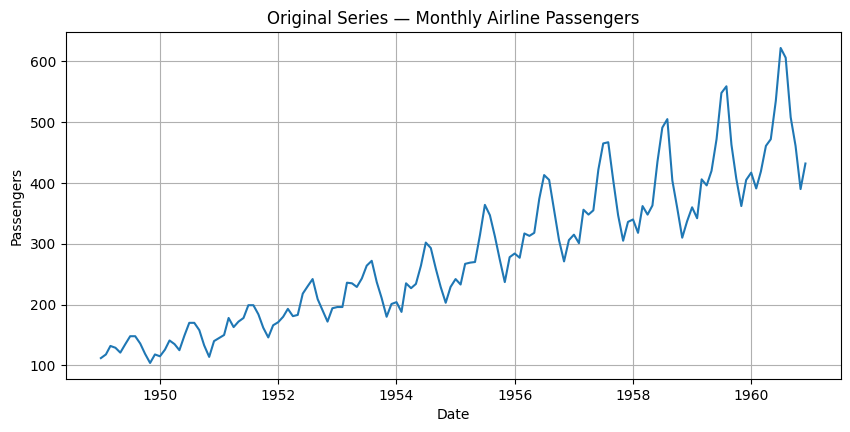

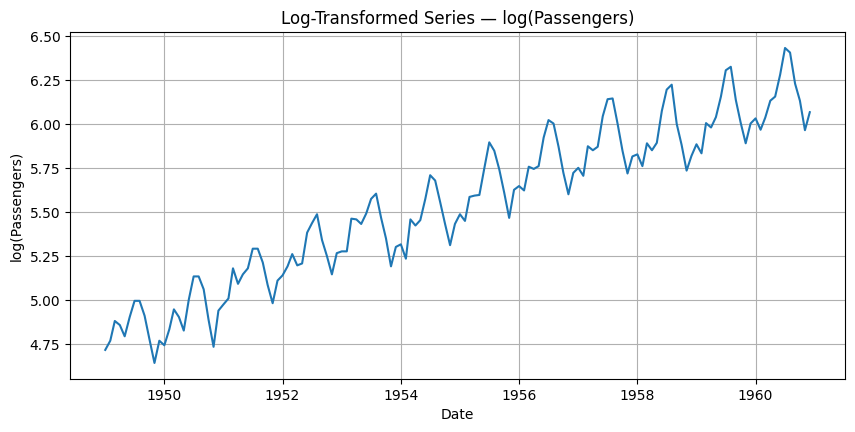

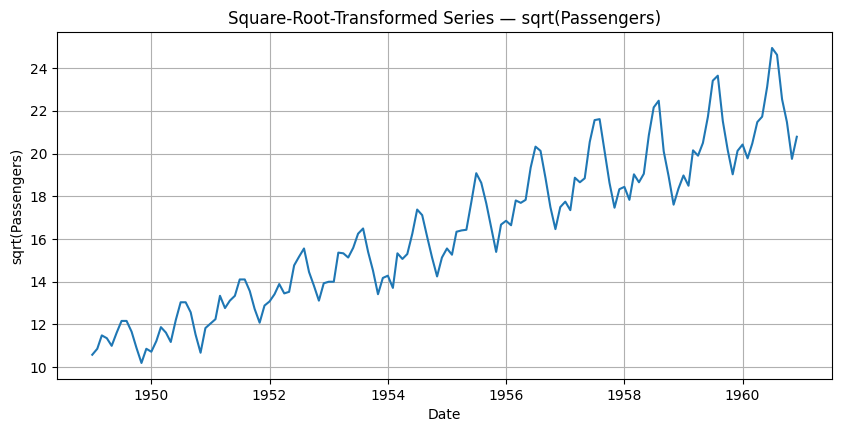

In [23]:
# Step 4: Plot original and transformed series
plt.figure(figsize=(10, 4.5))
plt.plot(series.index, series.values)
plt.title("Original Series — Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(series_log.index, series_log.values)
plt.title("Log-Transformed Series — log(Passengers)")
plt.xlabel("Date")
plt.ylabel("log(Passengers)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(series_sqrt.index, series_sqrt.values)
plt.title("Square-Root-Transformed Series — sqrt(Passengers)")
plt.xlabel("Date")
plt.ylabel("sqrt(Passengers)")
plt.grid(True)
plt.show()


=== Rolling Standard Deviation Comparison ===
Original:
  Mean rolling std (12m): 41.1311
  Median rolling std (12m): 36.4338
  Min/Max rolling std (12m): 13.1665 / 84.6173

Log-Transformed:
  Mean rolling std (12m): 0.1401
  Median rolling std (12m): 0.1408
  Min/Max rolling std (12m): 0.0875 / 0.1908

Sqrt-Transformed:
  Mean rolling std (12m): 1.1750
  Median rolling std (12m): 1.1512
  Min/Max rolling std (12m): 0.5755 / 1.9644



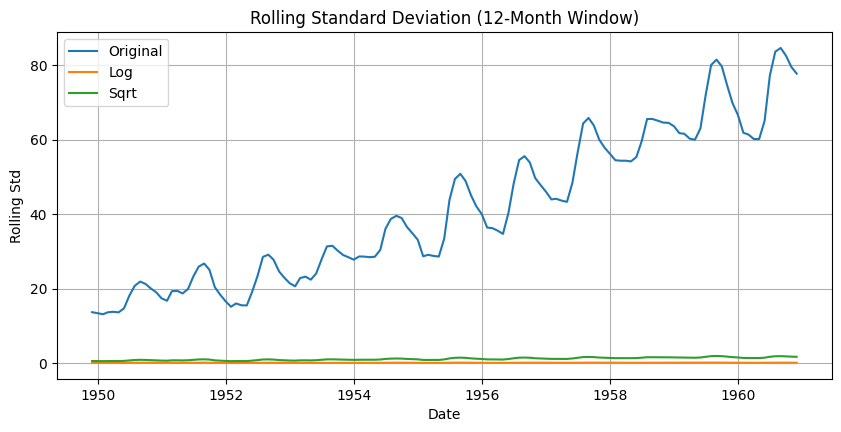

In [24]:
# Step 5: Quantify variance stabilization via rolling standard deviation
win = 12  # 12-month rolling window
roll_std_orig = series.rolling(window=win).std().rename("RollingStd_Orig")
roll_std_log = series_log.rolling(window=win).std().rename("RollingStd_Log")
roll_std_sqrt = series_sqrt.rolling(window=win).std().rename("RollingStd_Sqrt")

# Print summary statistics for rolling std to compare variability
def summarize_rolling_std(name, s):
    print(f"{name}:")
    print(f"  Mean rolling std ({win}m): {s.mean():.4f}")
    print(f"  Median rolling std ({win}m): {s.median():.4f}")
    print(f"  Min/Max rolling std ({win}m): {s.min():.4f} / {s.max():.4f}\n")

print("=== Rolling Standard Deviation Comparison ===")
summarize_rolling_std("Original", roll_std_orig)
summarize_rolling_std("Log-Transformed", roll_std_log)
summarize_rolling_std("Sqrt-Transformed", roll_std_sqrt)

# Optional: visualize rolling standard deviations
plt.figure(figsize=(10, 4.5))
plt.plot(roll_std_orig.index, roll_std_orig.values, label="Original")
plt.plot(roll_std_log.index, roll_std_log.values, label="Log")
plt.plot(roll_std_sqrt.index, roll_std_sqrt.values, label="Sqrt")
plt.title(f"Rolling Standard Deviation ({win}-Month Window)")
plt.xlabel("Date")
plt.ylabel("Rolling Std")
plt.legend()
plt.grid(True)
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on using transformations to stabilize the variance in a time series. The dataset was first loaded and converted into a proper datetime index so it could be analyzed over time. Then, the original passenger data was visualized to understand how the values change and how the variability increases over time. After that, two transformations were applied: logarithmic and square root, to reduce large fluctuations in the data. These transformed series were compared visually with the original series, showing that both transformations make the data more stable. A rolling standard deviation was also used to measure variability more clearly, and it showed that the log transformation especially reduced variance the most. Overall, the exercise demonstrated how transformations help make time series data more consistent and suitable for forecasting models.


#### **Exercise 7: Differencing to Achieve Stationarity**

**Objective:**  
Learn how to apply **differencing** techniques to remove trends and achieve stationarity in a time series. You will compare the original and differenced series visually and statistically.

**Instructions:**

1. **Load Dataset**  
   Use the **Seaborn Flights Dataset** and prepare it as in the previous exercises (create a datetime index from `year` and `month`, set frequency to monthly).

2. **Check Stationarity**  
   - Plot the original series to visually inspect trends.  
   - Apply the Augmented Dickey-Fuller (ADF) test to statistically check for stationarity.

3. **Apply First Differencing**  
   - Subtract each value from its previous observation (`.diff()`).
   - Drop missing values and recheck stationarity with ADF.

4. **Apply Seasonal Differencing**  
   - Subtract each value from its value 12 months ago (`.diff(12)`).
   - Drop missing values and recheck stationarity with ADF.

5. **Plot Results**  
   - Compare the original, first differenced, and seasonal differenced series side-by-side to observe the removal of trend and seasonality.

6. **Interpret Findings**  
   - Discuss how differencing impacted the ADF test results and what it implies for the time series.

---


In [25]:
# Exercise 7: Differencing to Achieve Stationarity
# ------------------------------------------------
# Goal: Apply first and seasonal differencing to remove trend/seasonality
#       and assess stationarity using the ADF test.

# Step 1: Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Step 2: Load and prepare the Flights dataset
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)
series = (
    flights.set_index("date")["passengers"]
    .asfreq("MS")              # Monthly-start frequency
    .rename("Passengers")
)


In [26]:
# Helper: ADF print function
def adf_report(ts, title="Series"):
    ts = ts.dropna()
    result = adfuller(ts, autolag="AIC")
    labels = ["ADF Statistic", "p-value", "# Lags Used", "# Observations Used"]
    print(f"\n=== ADF Test: {title} ===")
    for label, value in zip(labels, result[:4]):
        print(f"{label:>20}: {value}")
    print("Critical Values:")
    for k, v in result[4].items():
        print(f"{k:>20}: {v}")
    pval = result[1]
    if pval < 0.05:
        print("Conclusion: p-value < 0.05 → Reject H0 → Likely STATIONARY.")
    else:
        print("Conclusion: p-value ≥ 0.05 → Fail to reject H0 → Likely NON-STATIONARY.")


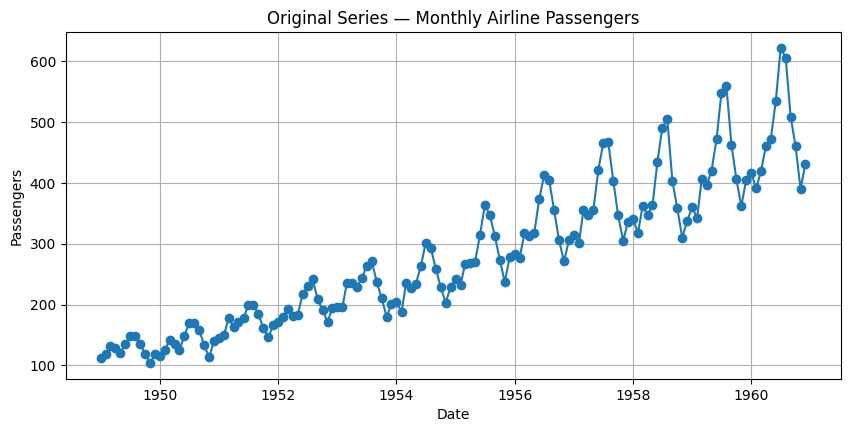


=== ADF Test: Original ===
       ADF Statistic: 0.8153688792060498
             p-value: 0.991880243437641
         # Lags Used: 13
 # Observations Used: 130
Critical Values:
                  1%: -3.4816817173418295
                  5%: -2.8840418343195267
                 10%: -2.578770059171598
Conclusion: p-value ≥ 0.05 → Fail to reject H0 → Likely NON-STATIONARY.


In [27]:
# Step 3: Visual inspection of original series + ADF
plt.figure(figsize=(10, 4.5))
plt.plot(series.index, series.values, marker="o", linestyle="-")
plt.title("Original Series — Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()
adf_report(series, "Original")


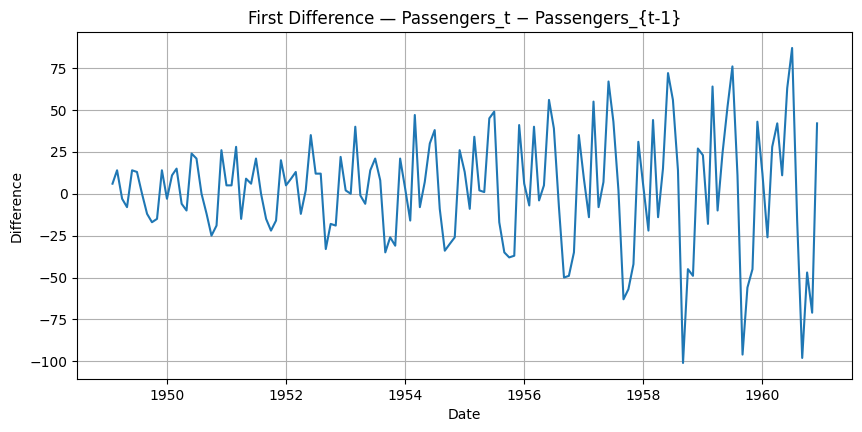


=== ADF Test: First Difference (d=1) ===
       ADF Statistic: -2.8292668241700047
             p-value: 0.05421329028382478
         # Lags Used: 12
 # Observations Used: 130
Critical Values:
                  1%: -3.4816817173418295
                  5%: -2.8840418343195267
                 10%: -2.578770059171598
Conclusion: p-value ≥ 0.05 → Fail to reject H0 → Likely NON-STATIONARY.


In [28]:
# Step 4: First differencing (remove trend)
series_diff1 = series.diff().rename("Diff1")
plt.figure(figsize=(10, 4.5))
plt.plot(series_diff1.index, series_diff1.values, linestyle="-")
plt.title("First Difference — Passengers_t − Passengers_{t-1}")
plt.xlabel("Date")
plt.ylabel("Difference")
plt.grid(True)
plt.show()
adf_report(series_diff1, "First Difference (d=1)")


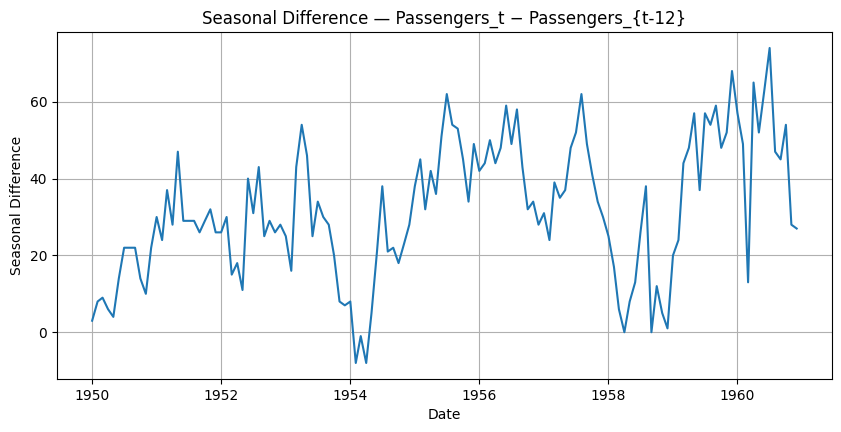


=== ADF Test: Seasonal Difference (D=1, m=12) ===
       ADF Statistic: -3.383020726492481
             p-value: 0.011551493085514952
         # Lags Used: 1
 # Observations Used: 130
Critical Values:
                  1%: -3.4816817173418295
                  5%: -2.8840418343195267
                 10%: -2.578770059171598
Conclusion: p-value < 0.05 → Reject H0 → Likely STATIONARY.


In [29]:
# Step 5: Seasonal differencing (remove yearly seasonality, period=12)
series_diff12 = series.diff(12).rename("Diff12")
plt.figure(figsize=(10, 4.5))
plt.plot(series_diff12.index, series_diff12.values, linestyle="-")
plt.title("Seasonal Difference — Passengers_t − Passengers_{t-12}")
plt.xlabel("Date")
plt.ylabel("Seasonal Difference")
plt.grid(True)
plt.show()
adf_report(series_diff12, "Seasonal Difference (D=1, m=12)")


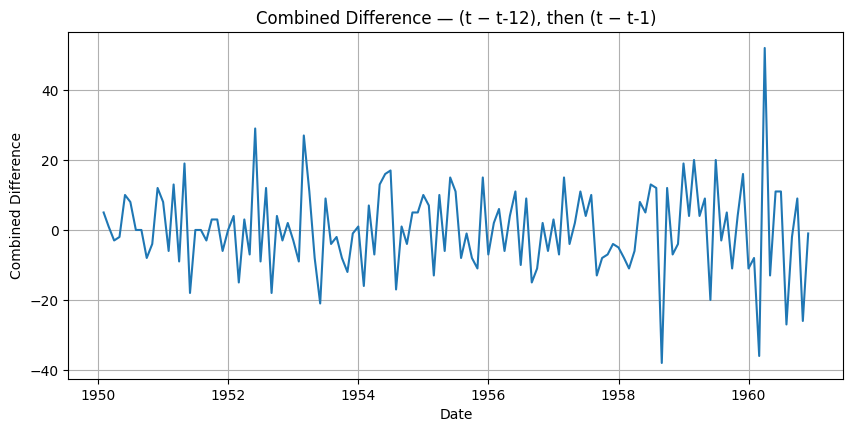


=== ADF Test: Combined Difference (d=1, D=1, m=12) ===
       ADF Statistic: -15.595618083746338
             p-value: 1.856511600123444e-28
         # Lags Used: 0
 # Observations Used: 130
Critical Values:
                  1%: -3.4816817173418295
                  5%: -2.8840418343195267
                 10%: -2.578770059171598
Conclusion: p-value < 0.05 → Reject H0 → Likely STATIONARY.


In [30]:
# Step 6: Combined differencing (first + seasonal)
series_diff12_1 = series_diff12.diff().rename("Diff12_1")
plt.figure(figsize=(10, 4.5))
plt.plot(series_diff12_1.index, series_diff12_1.values, linestyle="-")
plt.title("Combined Difference — (t − t-12), then (t − t-1)")
plt.xlabel("Date")
plt.ylabel("Combined Difference")
plt.grid(True)
plt.show()
adf_report(series_diff12_1, "Combined Difference (d=1, D=1, m=12)")

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on making a non-stationary time series stationary using differencing techniques. The dataset was first loaded and converted into a proper datetime index so it could be analyzed in a time-based format. The original series was then plotted and tested using the ADF test, which showed that it was not stationary due to a strong trend and seasonality. After that, first differencing was applied to remove the trend, but the series still did not fully become stationary based on the ADF results. Next, seasonal differencing was applied with a 12-month lag, which helped remove yearly seasonal patterns and improved stationarity. Finally, combining both first and seasonal differencing produced a fully stationary series according to the ADF test results. Overall, this exercise showed how differencing helps remove trend and seasonality step by step to prepare data for forecasting models.


#### **Exercise 8: Autocorrelation (ACF) and Partial Autocorrelation (PACF) Analysis**

**Objective:**  
Learn how to compute and interpret **autocorrelation** and **partial autocorrelation** plots to identify time dependencies in a stationary time series. These plots are essential for determining the order of AR (autoregressive) and MA (moving average) terms when building ARIMA models.

**Instructions:**

1. **Load the Dataset**  
   Use the **Flights dataset** from Seaborn and convert it into a stationary series by applying the differencing method used in the previous exercise.

2. **Plot ACF and PACF**  
   - Use `plot_acf()` to display autocorrelations at various lags.  
   - Use `plot_pacf()` to display partial autocorrelations at various lags.  

3. **Interpret the Plots**  
   - Identify significant spikes and determine possible AR and MA orders.  
   - Discuss how these insights help in model selection.

4. **Relate Findings to Differencing**  
   Explain how the differencing performed earlier impacts autocorrelation patterns.

---


In [31]:
# Exercise 8: Autocorrelation (ACF) and Partial Autocorrelation (PACF) Analysis
# -----------------------------------------------------------------------------
# Goal: Create a stationary series via differencing, then plot and interpret ACF/PACF.

# Step 1: Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Step 2: Load and prepare the Flights dataset
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b"
)
series = (
    flights.set_index("date")["passengers"]
    .asfreq("MS")          # Monthly-start frequency
    .rename("Passengers")
)


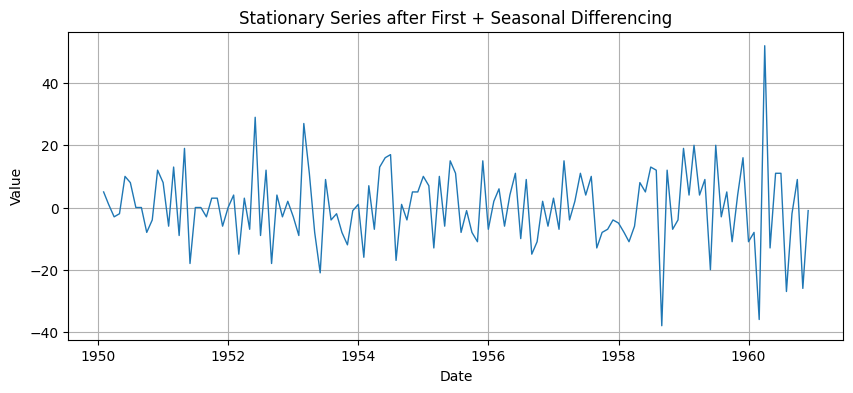

In [32]:
# Step 3: Make the series (approximately) stationary via differencing
# First difference (remove trend)
diff1 = series.diff()

# Seasonal difference (remove annual seasonality, m=12)
diff12 = series.diff(12)

# Combined difference (both)
stationary = diff12.diff().dropna().rename("StationarySeries")

# (Optional) Quick look at the stationary series
plt.figure(figsize=(10, 4))
plt.plot(stationary.index, stationary.values, linewidth=1)
plt.title("Stationary Series after First + Seasonal Differencing")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

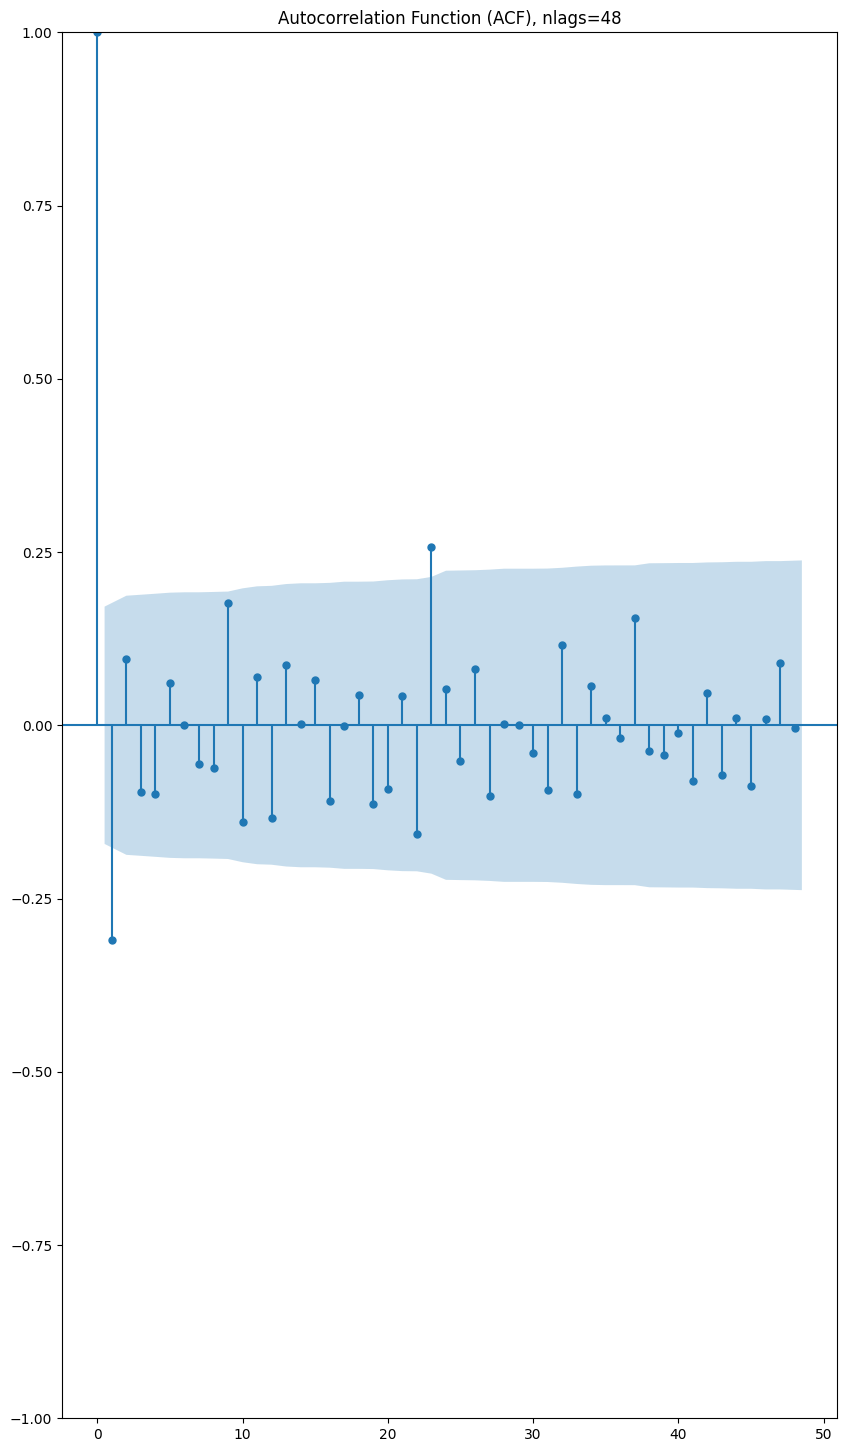

In [33]:
# Step 4: Plot ACF and PACF for the stationary series
# Choose nlags so we see multiple seasonal cycles (e.g., up to 48 months)
nlags = 48
alpha = 0.05  # 95% confidence intervals

plt.figure(figsize=(10, 4))
plot_acf(stationary, lags=nlags, alpha=alpha)
plt.title(f"Autocorrelation Function (ACF), nlags={nlags}")
plt.show()


<Figure size 1000x400 with 0 Axes>

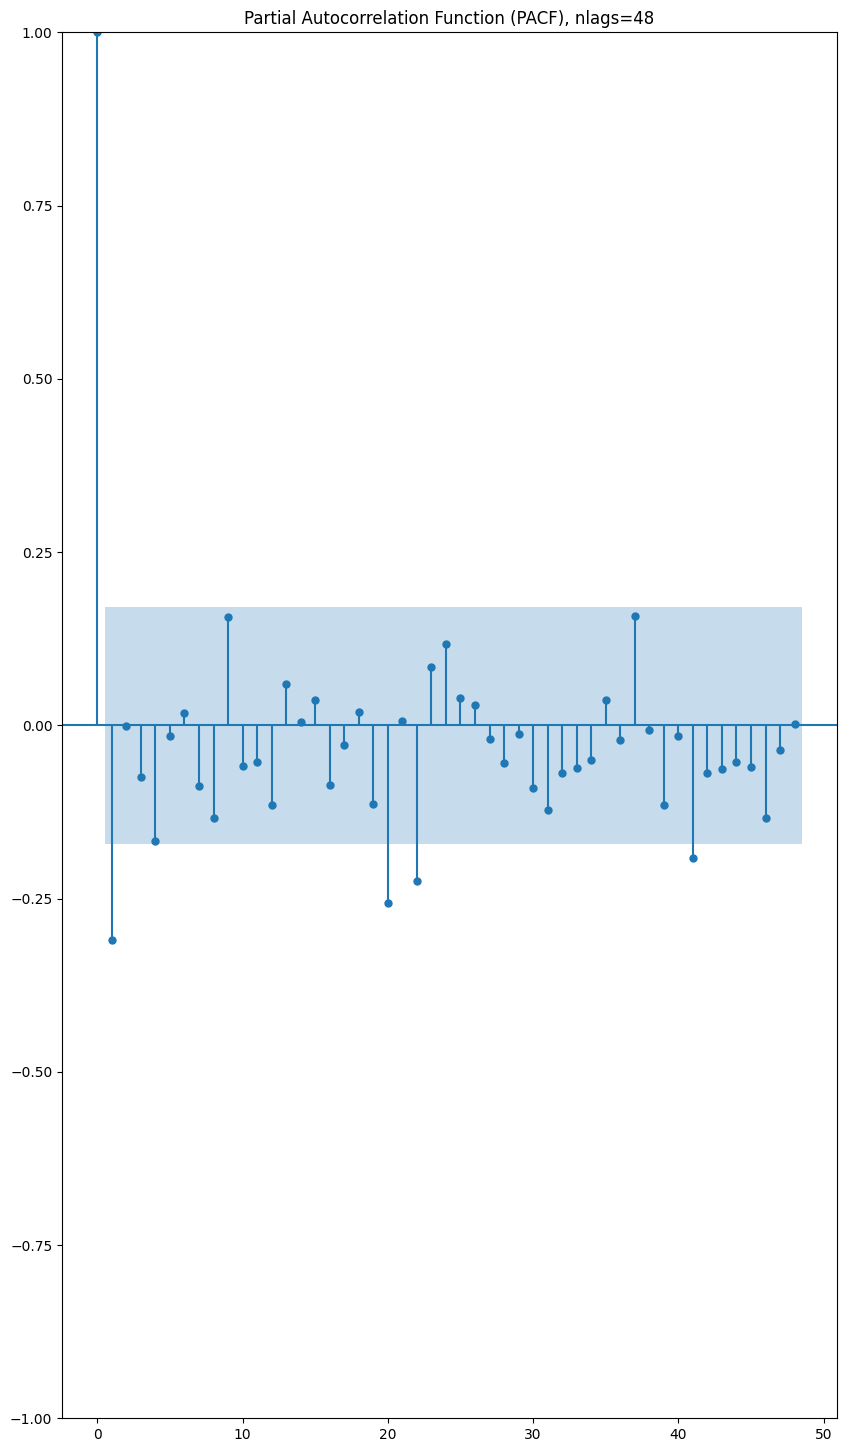

In [34]:
plt.figure(figsize=(10, 4))
# Yule-Walker/Burg can struggle at high lags; use 'ljungbox' default CI with method 'ywm'
plot_pacf(stationary, lags=nlags, alpha=alpha, method="ywm")
plt.title(f"Partial Autocorrelation Function (PACF), nlags={nlags}")
plt.show()

<Figure size 1000x400 with 0 Axes>

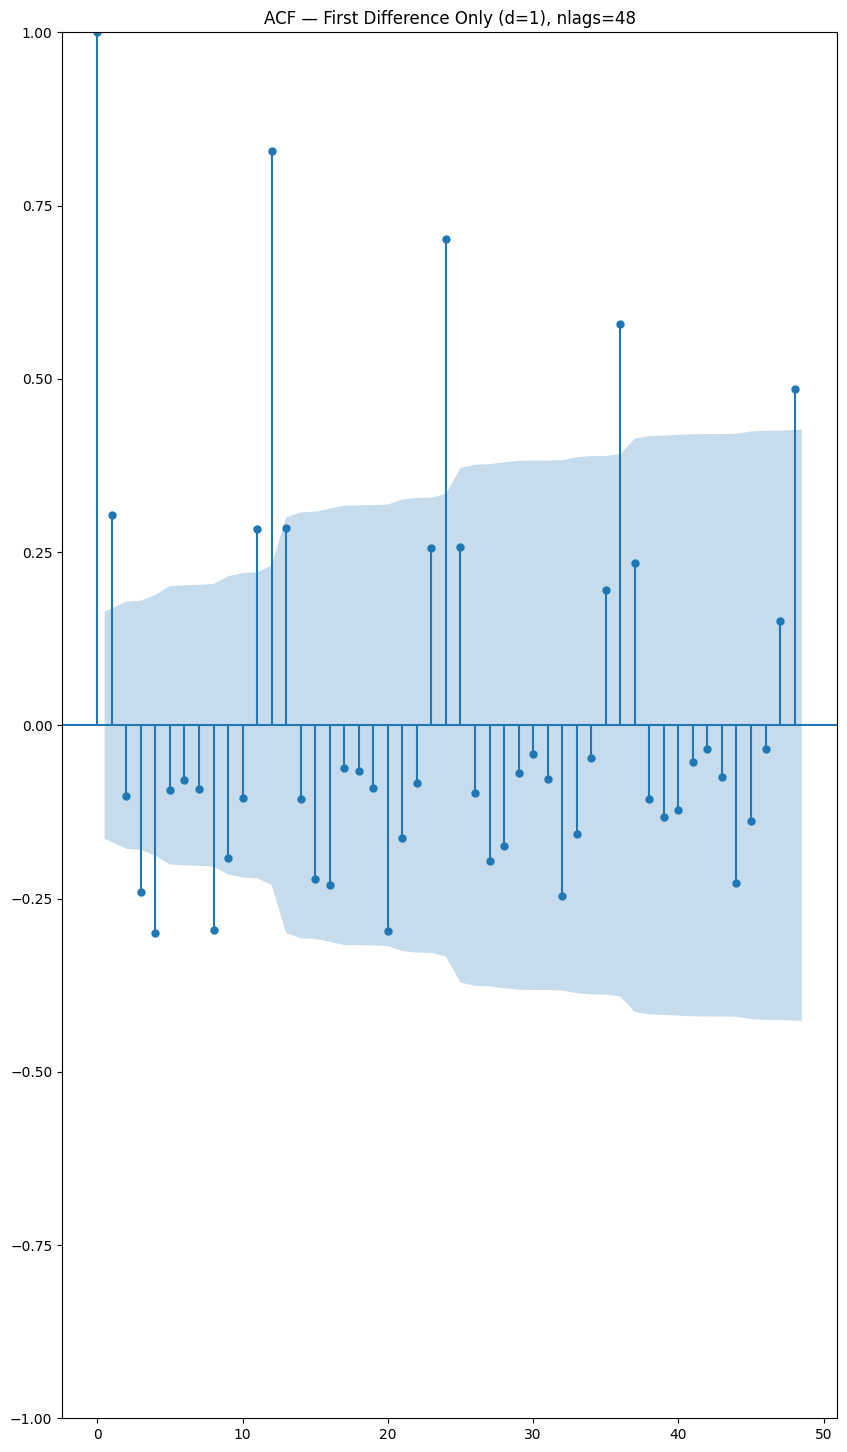

In [35]:
# Step 5: (Optional) ACF/PACF for first-only and seasonal-only differences for comparison
plt.figure(figsize=(10, 4))
plot_acf(diff1.dropna(), lags=nlags, alpha=alpha)
plt.title(f"ACF — First Difference Only (d=1), nlags={nlags}")
plt.show()


<Figure size 1000x400 with 0 Axes>

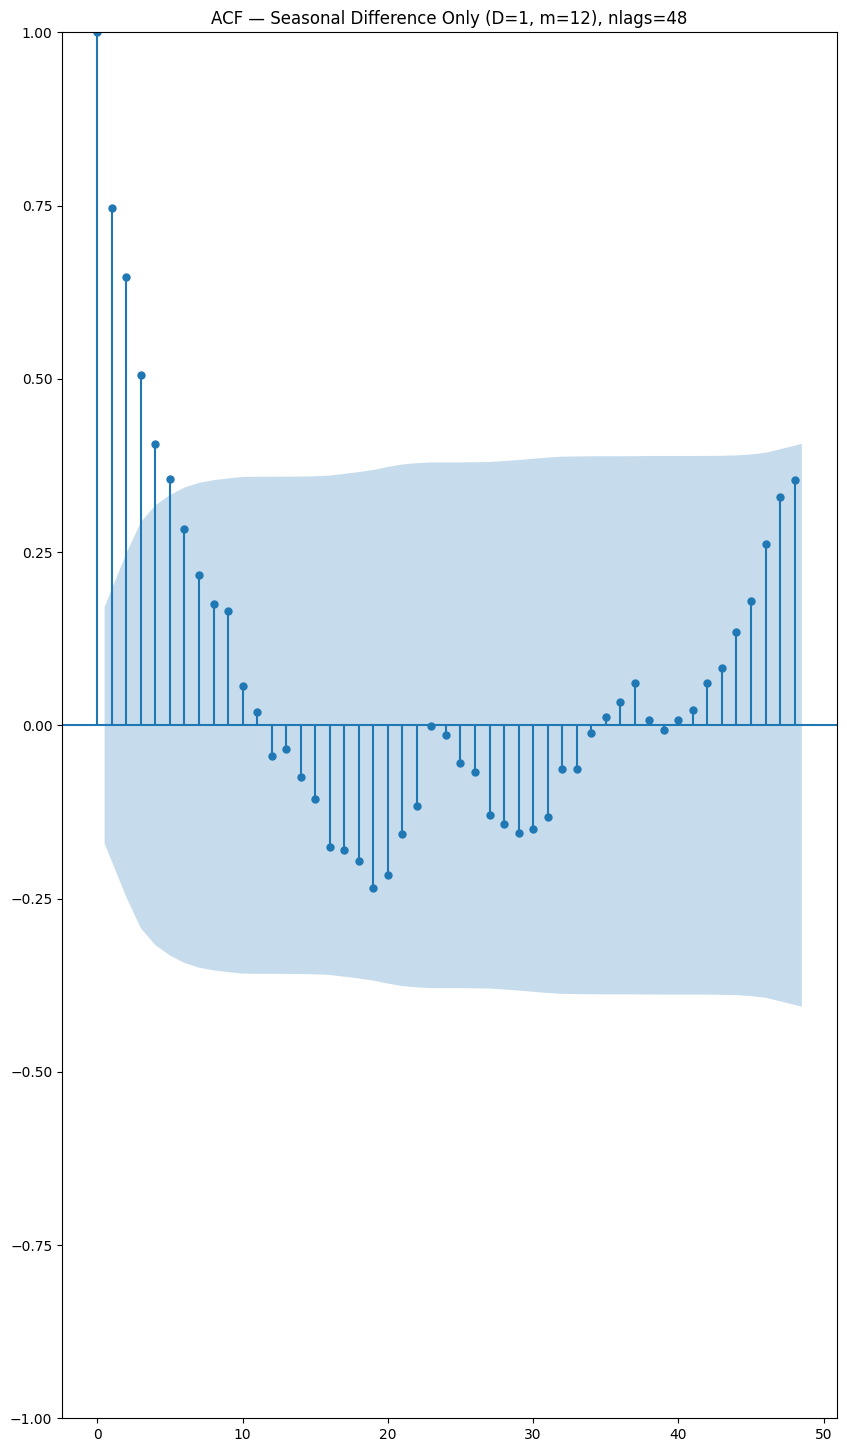

In [36]:
plt.figure(figsize=(10, 4))
plot_acf(diff12.dropna(), lags=nlags, alpha=alpha)
plt.title(f"ACF — Seasonal Difference Only (D=1, m=12), nlags={nlags}")
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding autocorrelation and partial autocorrelation using a stationary version of the flights time series. The dataset was first loaded and converted into a proper datetime index to prepare it for time series analysis. Then, differencing was applied to remove trend and seasonality, creating a stationary series. After that, ACF and PACF plots were generated to study how past values influence current values at different time lags. The ACF plot helped show the overall correlation pattern across lags, while the PACF plot helped identify the direct relationships at specific lags. These patterns are useful for deciding the AR and MA terms when building models like ARIMA. Overall, the exercise showed how transforming the data first makes it easier to interpret autocorrelation patterns and supports better model selection.


#### **Module 9.3: Classical Forecasting Models: ARIMA and Exponential Smoothing**

Classical forecasting models form the backbone of time series prediction, focusing on capturing patterns such as trend and seasonality to generate accurate forecasts.

Key models include:  
- **ARIMA (AutoRegressive Integrated Moving Average):**  
  Combines autoregression (AR), differencing (I) for stationarity, and moving average (MA) components to model various types of univariate time series data.  
- **Exponential Smoothing:**  
  Includes methods like Simple Exponential Smoothing, Holt’s Linear Trend, and Holt-Winters Seasonal models that apply weighted averages of past observations, emphasizing recent data for trend and seasonality capture.

You will learn how to select, fit, and interpret these models to forecast time series data effectively.

---


#### **Exercise 9: Building and Evaluating an ARIMA Model for Univariate Forecasting**

**Objective:**  
Fit and evaluate an **ARIMA** model on a univariate time series. You will (1) visualize the series, (2) assess stationarity, (3) difference if needed, (4) use ACF/PACF and a compact AIC grid search to choose \((p,d,q)\), (5) fit the model, (6) diagnose residuals, and (7) forecast and score performance.

**Dataset:**  
A **synthetic monthly univariate series (2010–2019)** generated from an ARMA-like process with a small drift (no explicit seasonality). This keeps the exercise fully offline and reproducible while exhibiting typical ARIMA behavior.

**What you will do:**  
- Load and plot the series; create a train/test split (last 12 months as test).  
- Run **ADF** on the training set; difference once if non-stationary.  
- Inspect **ACF/PACF** on level or differenced series.  
- Perform a small **AIC grid search** over \((p,d,q)\).  
- Fit the best ARIMA model and check **residual diagnostics** (plot, Ljung–Box).  
- **Forecast** the test horizon with intervals and compute **MAE, RMSE, MAPE**.  
- Interpret results and note model assumptions/limitations.

---

In [37]:
# Exercise 9 — ARIMA Univariate Forecasting (Matplotlib ≥3.6 compatible)

# -----------------------------
# 0) Imports & Config
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product
from math import sqrt

np.random.seed(42)  # reproducibility
plt.close('all')

# -----------------------------
# 1) Create a synthetic monthly time series (2010-01 to 2019-12)
#    ARMA-like process with small drift (no explicit seasonality)
# -----------------------------
n_years = 10
n = 12 * n_years  # 120 months
dates = pd.date_range(start="2010-01-01", periods=n, freq="MS")

# Generate innovations and build ARMA(1,1)-like series with drift
eps = np.random.normal(loc=0.0, scale=1.0, size=n)
phi = 0.5   # AR(1)
theta = 0.3 # MA(1)
drift = 0.2

y = np.zeros(n)
e_prev = 0.0
for t in range(1, n):
    # AR(1) + MA(1) + small drift
    y[t] = drift + phi * y[t-1] + eps[t] + theta * e_prev
    e_prev = eps[t]

series = pd.Series(y, index=dates, name="value")


In [38]:
# -----------------------------
# 2) Train/Test split (last 12 months for testing)
# -----------------------------
test_horizon = 12
train = series.iloc[:-test_horizon]
test = series.iloc[-test_horizon:]



ADF on TRAIN (level)
- ADF Statistic: -5.359710
- p-value: 0.000004
- Used Lags: 1.000000
- N Obs: 106.000000
- Critical Value 1%: -3.493602
- Critical Value 5%: -2.889217
- Critical Value 10%: -2.581533


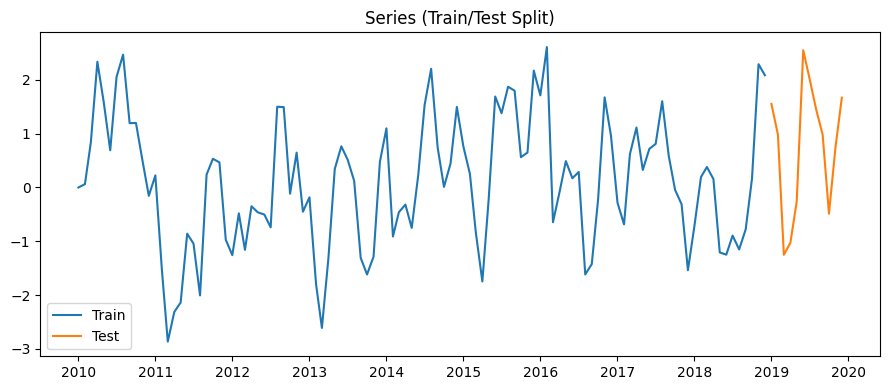

In [39]:
# -----------------------------
# 3) Stationarity check (ADF) & optional differencing
# -----------------------------
def adf_report(x, title="ADF Test"):
    res = adfuller(x, autolag="AIC")
    out = {
        "ADF Statistic": res[0],
        "p-value": res[1],
        "Used Lags": res[2],
        "N Obs": res[3]
    }
    print(f"\n{title}")
    for k, v in out.items():
        print(f"- {k}: {v:.6f}")
    for key, val in res[4].items():
        print(f"- Critical Value {key}: {val:.6f}")
    return res[1]  # return p-value

pval_level = adf_report(train, title="ADF on TRAIN (level)")
needs_diff = pval_level > 0.05  # simple rule

# Plot level series
fig1 = plt.figure(figsize=(9,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Series (Train/Test Split)")
plt.legend()
plt.tight_layout()

# If needed, inspect first difference on train (for diagnostics only)
if needs_diff:
    dtrain = train.diff().dropna()
    pval_diff = adf_report(dtrain, title="ADF on TRAIN (first difference)")
    fig2 = plt.figure(figsize=(9,3))
    plt.plot(dtrain)
    plt.title("First Difference (Train)")
    plt.tight_layout()


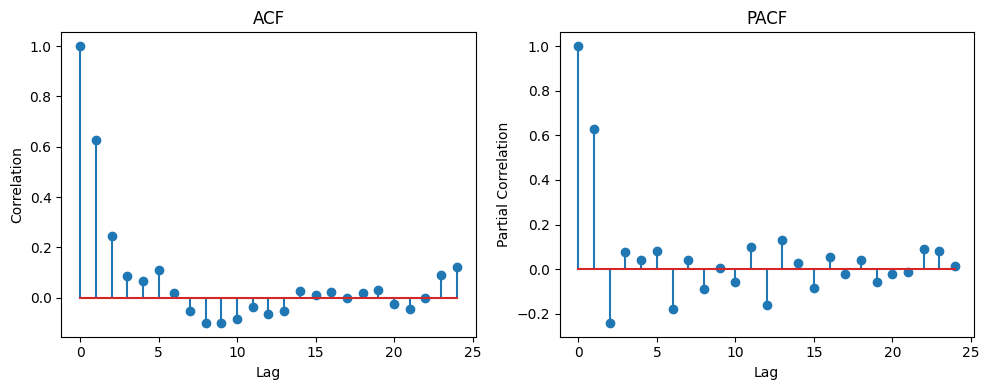

In [40]:
# -----------------------------
# 4) ACF / PACF diagnostics (level or differenced depending on stationarity)
#    (Removed deprecated 'use_line_collection' arg for Matplotlib ≥3.6)
# -----------------------------
diag_ser = train if not needs_diff else train.diff().dropna()

lag_max = 24
acf_vals = acf(diag_ser, nlags=lag_max, fft=True)
pacf_vals = pacf(diag_ser, nlags=lag_max, method="ywm")

fig3 = plt.figure(figsize=(10,4))
ax1 = plt.subplot(1,2,1)
ax1.stem(range(len(acf_vals)), acf_vals)  # compatible call
ax1.set_title("ACF")
ax1.set_xlabel("Lag")
ax1.set_ylabel("Correlation")

ax2 = plt.subplot(1,2,2)
ax2.stem(range(len(pacf_vals)), pacf_vals)  # compatible call
ax2.set_title("PACF")
ax2.set_xlabel("Lag")
ax2.set_ylabel("Partial Correlation")
plt.tight_layout()


In [41]:
# -----------------------------
# 5) Model selection by small AIC grid search
#    Search p,q in [0..3], d in {0,1} (constrained by ADF result)
# -----------------------------
p_values = range(0, 4)
d_values = [0, 1] if needs_diff else [0]
q_values = range(0, 4)

def fit_arima_aic(y_train, order):
    try:
        model = SARIMAX(y_train, order=order, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res.aic, res
    except Exception:
        return np.inf, None

candidates = list(product(p_values, d_values, q_values))
results = []
best_aic = np.inf
best_res = None
best_order = None

for (p, d, q) in candidates:
    aic, res = fit_arima_aic(train, (p, d, q))
    results.append(((p, d, q), aic))
    if aic < best_aic:
        best_aic = aic
        best_res = res
        best_order = (p, d, q)

# Sort & print top 5 by AIC
results_sorted = sorted(results, key=lambda x: x[1])[:5]
print("\nTop candidates by AIC:")
for (ordr, aic) in results_sorted:
    print(f"- order={ordr}  AIC={aic:.2f}")

print(f"\nSelected ARIMA order (p,d,q) = {best_order} with AIC={best_aic:.2f}")



Top candidates by AIC:
- order=(3, 0, 3)  AIC=280.93
- order=(2, 0, 3)  AIC=280.93
- order=(0, 0, 3)  AIC=281.84
- order=(1, 0, 3)  AIC=283.52
- order=(3, 0, 1)  AIC=286.12

Selected ARIMA order (p,d,q) = (3, 0, 3) with AIC=280.93



Ljung-Box (lag=12) on residuals:
     lb_stat  lb_pvalue
12  8.384328   0.754422


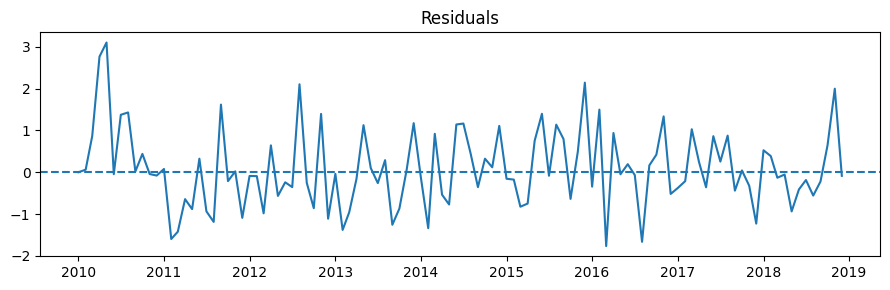

In [42]:
# -----------------------------
# 6) Residual diagnostics (white-noise check)
# -----------------------------
resid = best_res.resid

fig4 = plt.figure(figsize=(9,3))
plt.plot(resid)
plt.axhline(0, linestyle="--")
plt.title("Residuals")
plt.tight_layout()

lj = acorr_ljungbox(resid, lags=[12], return_df=True)  # 12-lag LB test
print("\nLjung-Box (lag=12) on residuals:")
print(lj)


In [43]:
# -----------------------------
# 7) Forecast on the test horizon & evaluate
# -----------------------------
fcst = best_res.get_forecast(steps=test_horizon)
pred_mean = fcst.predicted_mean
pred_ci = fcst.conf_int()

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(1e-8, np.abs(y_true)))) * 100

metrics = {
    "MAE": mae(test.values, pred_mean.values),
    "RMSE": rmse(test.values, pred_mean.values),
    "MAPE (%)": mape(test.values, pred_mean.values),
}
print("\nTest set performance:")
for k, v in metrics.items():
    print(f"- {k}: {v:.4f}")



Test set performance:
- MAE: 1.1942
- RMSE: 1.3587
- MAPE (%): 95.8594


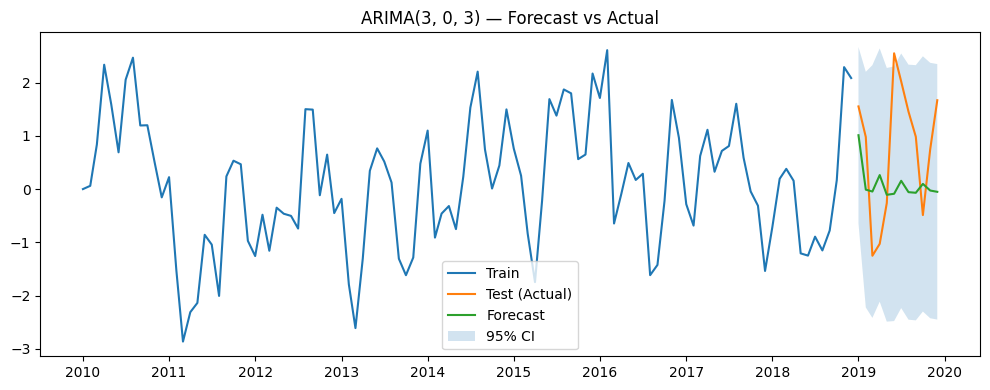

In [44]:
# -----------------------------
# 8) Plot: Forecast vs. Actual with 95% CI
# -----------------------------
fig5 = plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test (Actual)")
plt.plot(test.index, pred_mean.values, label="Forecast")
plt.fill_between(test.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.2, label="95% CI")
plt.title(f"ARIMA{best_order} — Forecast vs Actual")
plt.legend()
plt.tight_layout()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on building and evaluating an ARIMA model for time series forecasting. The process began by generating and preparing a univariate time series and splitting it into training and testing sets to evaluate performance properly. Then, the data was checked for stationarity using the ADF test, which helped decide whether differencing was needed. After that, ACF and PACF plots were used to understand the relationships in the data and guide model selection. A small grid search based on AIC was then performed to find the best ARIMA (p, d, q) combination. The selected model was fitted, and residuals were checked using diagnostics like the Ljung-Box test to ensure they behaved like random noise. Finally, the model was used to forecast future values, and the predictions were compared with actual values using error metrics. Overall, this exercise showed how ARIMA combines statistical testing, parameter tuning, and validation to create reliable forecasts.


#### **Exercise 10: Forecasting with Simple and Holt’s Linear Exponential Smoothing**

**Objective:**  
Learn how to fit and evaluate **Simple Exponential Smoothing (SES)** and **Holt’s Linear Trend** models on a univariate series. You will (1) visualize and split the data, (2) fit SES and Holt, (3) forecast the test horizon, and (4) compare basic error metrics.

**Dataset:**  
A synthetic **monthly** series (2010–2019) with a mild **linear trend** and noise (no explicit seasonality) to highlight the strengths of SES (level only) vs. Holt (level + trend).

**What you will do:**  
- Create and visualize a monthly time series; hold out the last 12 months for testing.  
- Fit **SES** and **Holt (additive trend, optionally damped)** on the training data.  
- Forecast 12 months ahead and compute **MAE** and **RMSE**.  
- Plot forecasts vs. actuals and briefly interpret which method fits trend better.

---

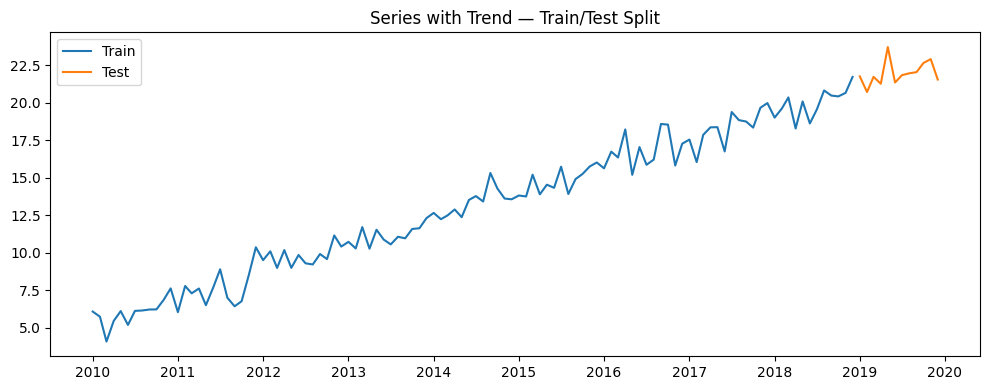

In [45]:
# Exercise 10 — Simple & Holt’s Linear Exponential Smoothing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

np.random.seed(10)
plt.close('all')

# 1) Synthetic monthly series (trend + noise), 2010–2019
n_years = 10
n = 12 * n_years
dates = pd.date_range("2010-01-01", periods=n, freq="MS")

trend = 0.15 * np.arange(n)
noise = np.random.normal(0, 0.8, size=n)
y = 5 + trend + noise
series = pd.Series(y, index=dates, name="value")

# 2) Train/Test split (last 12 months = test)
H = 12
train = series.iloc[:-H]
test  = series.iloc[-H:]

# 3) Visualize
fig = plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test")
plt.title("Series with Trend — Train/Test Split")
plt.legend(); plt.tight_layout()

In [46]:
# 4) Fit SES (level only)
ses_model = SimpleExpSmoothing(train, initialization_method="estimated")
ses_fit = ses_model.fit(optimized=True)
ses_fc = ses_fit.forecast(H)


In [47]:
# 5) Fit Holt’s linear trend (optionally try damped=True)
holt_model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
holt_fit = holt_model.fit(optimized=True)
holt_fc = holt_fit.forecast(H)


In [48]:
# 6) Metrics
def mae(y_true, y_pred): return float(np.mean(np.abs(y_true - y_pred)))
def rmse(y_true, y_pred): return float(np.sqrt(np.mean((y_true - y_pred)**2)))

scores = pd.DataFrame({
    "Model": ["SES", "Holt-Linear"],
    "MAE":  [mae(test.values, ses_fc.values),  mae(test.values, holt_fc.values)],
    "RMSE": [rmse(test.values, ses_fc.values), rmse(test.values, holt_fc.values)],
}).set_index("Model")

print("\nTest performance (lower is better):")
print(scores)



Test performance (lower is better):
                  MAE      RMSE
Model                          
SES          0.990327  1.216389
Holt-Linear  0.548002  0.758873


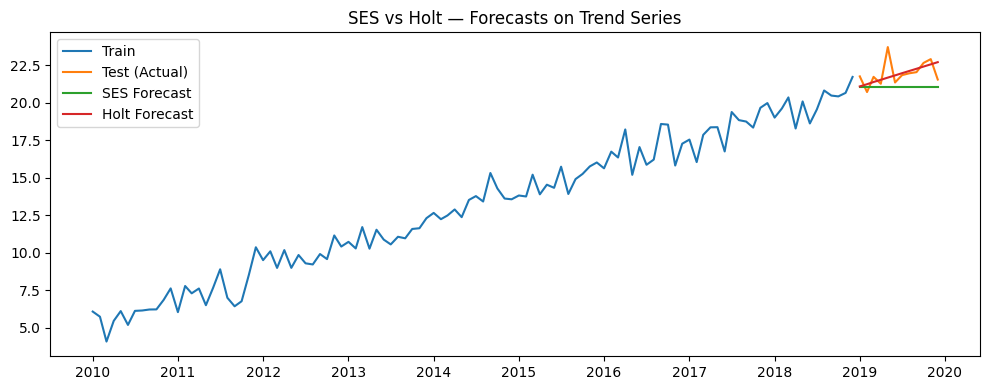

In [49]:
# 7) Plot forecasts
fig = plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index,  test.values,  label="Test (Actual)")
plt.plot(test.index,  ses_fc.values,  label="SES Forecast")
plt.plot(test.index,  holt_fc.values, label="Holt Forecast")
plt.title("SES vs Holt — Forecasts on Trend Series")
plt.legend(); plt.tight_layout()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on comparing Simple Exponential Smoothing (SES) and Holt’s Linear Trend method for forecasting a time series with a trend. The dataset was first created and split into training and testing sets so that the last 12 months could be used for evaluation. Then, the series was visualized to understand its overall upward trend and noise. SES was applied first, which focuses only on the level of the data and does not capture trend. After that, Holt’s method was used, which includes both level and trend, making it more suitable for this dataset. Both models were used to forecast future values, and their predictions were compared with the actual test data. Error metrics like MAE and RMSE showed that Holt’s method performed better than SES because it could follow the trend more effectively. Overall, the exercise showed how choosing the right exponential smoothing method depends on whether trend is present in the data.


#### **Module 9.4: Model Diagnostics, Evaluation, and Applications**

Model diagnostics are essential to assess the adequacy and accuracy of time series forecasting models. Proper evaluation ensures that forecasts are reliable and actionable.

In this sub-module, you will learn how to:  
- Perform **residual analysis** to check for randomness and absence of autocorrelation, indicating a good model fit.  
- Use performance metrics such as **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Percentage Error (MAPE)** to quantify forecast accuracy.  
- Apply time series forecasting methods to practical applications in engineering (e.g., equipment failure prediction), finance (e.g., stock prices), and operations (e.g., inventory demand forecasting).  
- Interpret model outputs and make informed decisions based on forecast results.

Mastering diagnostics and evaluation techniques helps ensure your models are robust and valuable in real-world scenarios.

---

#### **Exercise 11: Residual Analysis and White Noise Testing in Forecasting Models**

**Objective:**  
Learn how to analyze model residuals to verify if they resemble white noise, indicating a well-fitted time series model. You will (1) fit a forecasting model, (2) plot residuals, (3) check autocorrelation in residuals, and (4) perform statistical tests to confirm randomness.

**Dataset:**  
We will generate a synthetic monthly time series (2015–2024) with a linear trend and seasonality. This ensures the residual analysis steps are clearly visible and reproducible.

**What you will do:**  
- Create and visualize the synthetic series.  
- Fit a SARIMA model to the training data.  
- Plot residuals and their histogram to check distribution.  
- Plot the ACF of residuals to detect autocorrelation.  
- Perform the **Ljung–Box test** to statistically assess whether residuals are uncorrelated.  
- Interpret the results to decide if the model is adequate.

---

In [50]:
# Exercise 11 — Residual Analysis and White Noise Testing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

np.random.seed(42)
plt.close('all')

# 1) Create synthetic monthly series (trend + seasonality + noise)
n_years = 10
n = 12 * n_years
dates = pd.date_range("2015-01-01", periods=n, freq="MS")

trend = 0.2 * np.arange(n)
seasonal_pattern = np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonal_pattern + noise
series = pd.Series(y, index=dates, name="value")

In [51]:
# 2) Train/Test split (last 12 months = test)
H = 12
train = series.iloc[:-H]
test = series.iloc[-H:]


In [52]:
# 3) Fit SARIMA model (pre-selected order for speed)
order = (1,1,1)
seasonal_order = (1,0,1,12)
model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
fit_res = model.fit(disp=False)


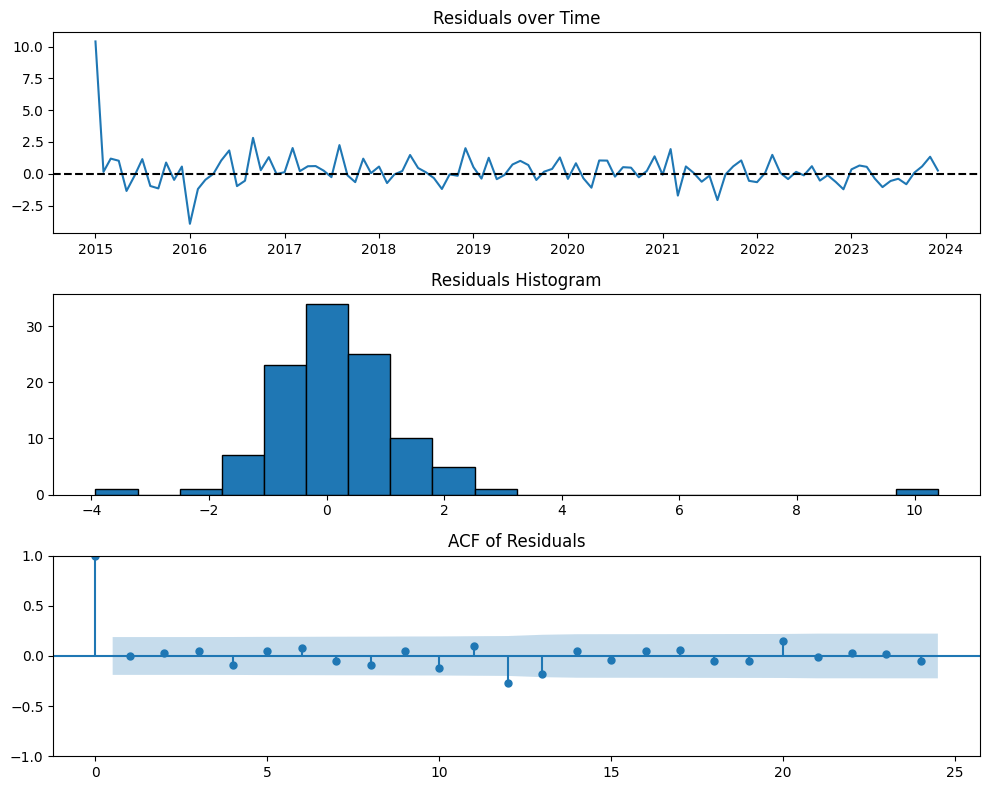

In [53]:
# 4) Get residuals
resid = fit_res.resid

# 5) Plot residuals
fig, axes = plt.subplots(3, 1, figsize=(10,8))
axes[0].plot(resid)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Residuals over Time")

axes[1].hist(resid, bins=20, edgecolor='black')
axes[1].set_title("Residuals Histogram")

plot_acf(resid, ax=axes[2], lags=24)
axes[2].set_title("ACF of Residuals")

plt.tight_layout()


In [54]:
# 6) Ljung–Box test for autocorrelation
ljung_box = acorr_ljungbox(resid, lags=[12], return_df=True)
print("\nLjung–Box test results (lag=12):")
print(ljung_box)


Ljung–Box test results (lag=12):
      lb_stat  lb_pvalue
12  15.574379   0.211517


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on checking whether a forecasting model is well-fitted by analyzing its residuals. The process began by creating a synthetic time series with trend, seasonality, and noise, and then splitting it into training and testing sets. A SARIMA model was fitted on the training data to capture the underlying patterns in the series. After fitting the model, the residuals were extracted and visualized using line plots and histograms to check if they looked random and normally distributed. The ACF plot of the residuals was also used to see if any autocorrelation was still present. Finally, the Ljung–Box test was applied, and the results showed no significant autocorrelation in the residuals, suggesting they behave like white noise. Overall, the exercise demonstrated how residual analysis helps confirm whether a model is adequate and whether it has successfully captured the structure in the data.


#### **Exercise 12: Comparing Forecast Accuracy Using MAE, RMSE, and MAPE**

**Objective:**  
Learn how to compare forecast accuracy across multiple models using standard error metrics — **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Percentage Error (MAPE)**. You will (1) fit different forecasting models, (2) generate forecasts for the same test set, and (3) evaluate and rank them based on the metrics.

**Dataset:**  
We will use a synthetic monthly time series (2015–2024) with a mild trend and seasonality, ensuring reproducibility and visible differences in model performance.

**What you will do:**  
- Create and visualize the synthetic series, splitting into training and testing sets.  
- Fit three models: **Naïve**, **Holt’s Linear Trend**, and **SARIMA**.  
- Forecast the next 12 months using each model.  
- Compute **MAE**, **RMSE**, and **MAPE** for each model.  
- Rank models and interpret which one fits best for this dataset.

---

In [55]:
# Exercise 12 — Comparing Forecast Accuracy Using MAE, RMSE, and MAPE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)
plt.close('all')

# 1) Create synthetic monthly series (trend + seasonality + noise)
n_years = 10
n = 12 * n_years
dates = pd.date_range("2015-01-01", periods=n, freq="MS")

trend = 0.15 * np.arange(n)
seasonal_pattern = np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 0.8, size=n)

y = 20 + trend + seasonal_pattern + noise
series = pd.Series(y, index=dates, name="value")

# 2) Train/Test split (last 12 months = test)
H = 12
train = series.iloc[:-H]
test = series.iloc[-H:]


In [56]:
# 3) Model 1: Naïve Forecast (last observation carried forward)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# 4) Model 2: Holt’s Linear Trend
holt_model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
holt_fit = holt_model.fit(optimized=True)
holt_forecast = holt_fit.forecast(H)

# 5) Model 3: SARIMA
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,12),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.get_forecast(steps=H).predicted_mean


In [57]:
# 6) Accuracy metrics
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return sqrt(np.mean((y_true - y_pred)**2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = pd.DataFrame({
    "Model": ["Naïve", "Holt's Linear", "SARIMA(1,1,1)(1,0,1,12)"],
    "MAE": [
        mae(test.values, naive_forecast.values),
        mae(test.values, holt_forecast.values),
        mae(test.values, sarima_forecast.values)
    ],
    "RMSE": [
        rmse(test.values, naive_forecast.values),
        rmse(test.values, holt_forecast.values),
        rmse(test.values, sarima_forecast.values)
    ],
    "MAPE (%)": [
        mape(test.values, naive_forecast.values),
        mape(test.values, holt_forecast.values),
        mape(test.values, sarima_forecast.values)
    ]
})

# Rank by RMSE
results = results.sort_values("RMSE")
print("\nForecast Accuracy Comparison:")
print(results)



Forecast Accuracy Comparison:
                     Model       MAE      RMSE  MAPE (%)
2  SARIMA(1,1,1)(1,0,1,12)  0.540344  0.722968  1.442309
1            Holt's Linear  0.812606  1.097277  2.167217
0                    Naïve  1.451895  1.751729  3.843252


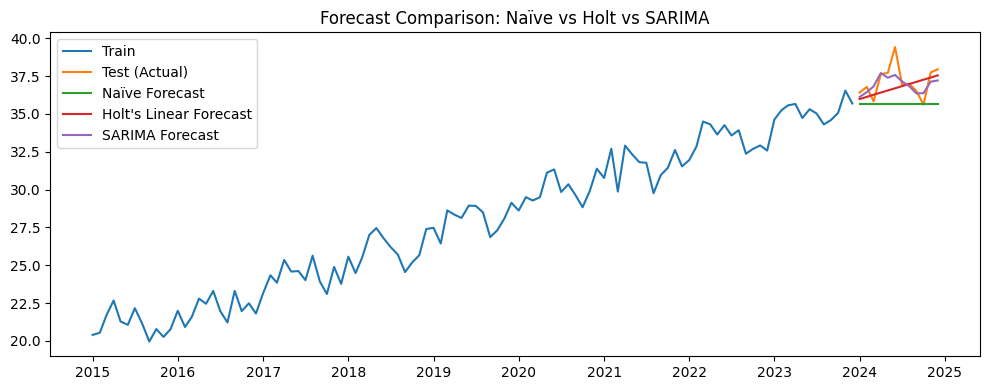

In [58]:
# 7) Plot forecasts
fig = plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test (Actual)")
plt.plot(test.index, naive_forecast.values, label="Naïve Forecast")
plt.plot(test.index, holt_forecast.values, label="Holt's Linear Forecast")
plt.plot(test.index, sarima_forecast.values, label="SARIMA Forecast")
plt.title("Forecast Comparison: Naïve vs Holt vs SARIMA")
plt.legend(); plt.tight_layout()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on comparing different forecasting models using common accuracy metrics. The dataset was first created and split into training and testing sets so that the last 12 months could be used for evaluation. Then, the data was visualized to understand the overall trend, seasonality, and noise in the series. Three forecasting methods were applied: Naïve, Holt’s Linear Trend, and SARIMA. Each model generated forecasts for the same test period, allowing a fair comparison. The performance of each model was then evaluated using MAE, RMSE, and MAPE, which helped measure prediction errors in different ways. The results showed that SARIMA performed the best, followed by Holt’s method, while the Naïve approach had the highest error. Overall, this exercise demonstrated how model performance can be objectively compared using error metrics to choose the most accurate forecasting method.


#### **Exercise 13: Cross-Validation for Time Series Models (Rolling Forecast Origin)**

**Objective:**  
Learn how to perform **time series cross-validation** using the **rolling forecast origin** method. This approach evaluates model performance across multiple train/test splits to get a more reliable estimate of forecast accuracy.

**Dataset:**  
We will use a synthetic monthly time series (2015–2024) with trend and seasonality, ensuring reproducibility and consistent evaluation.

**What you will do:**  
- Create and visualize the synthetic series.  
- Use the rolling forecast origin method to create multiple train/test splits.  
- Fit a forecasting model (Holt’s Linear Trend) at each step.  
- Generate 1-step-ahead forecasts and collect error metrics.  
- Average the results to estimate overall model performance.

---

In [59]:
# Exercise 13 — Cross-Validation for Time Series Models (Rolling Forecast Origin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)
plt.close('all')

# 1) Create synthetic monthly series (trend + seasonality + noise)
n_years = 10
n = 12 * n_years
dates = pd.date_range("2015-01-01", periods=n, freq="MS")

trend = 0.15 * np.arange(n)
seasonal_pattern = np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 0.8, size=n)

y = 50 + trend + seasonal_pattern + noise
series = pd.Series(y, index=dates, name="value")


In [60]:
# 2) Metric helpers
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


In [61]:
# 3) Rolling forecast origin CV
T0 = len(series) - 24  # keep last 24 months for CV
errors_mae, errors_rmse = [], []

for i in range(T0, len(series) - 1):
    train = series.iloc[:i]
    test_point = series.iloc[i]

    model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
    fit = model.fit(optimized=True)

    # Use iloc to avoid FutureWarning
    forecast = float(fit.forecast(1).iloc[0])

    errors_mae.append(mae(test_point, forecast))
    errors_rmse.append(rmse(test_point, forecast))


In [62]:
# 4) Average metrics
cv_results = {
    "MAE": float(np.mean(errors_mae)),
    "RMSE": float(np.mean(errors_rmse))
}

print("\nRolling Forecast Origin CV Results:")
print(f"Average MAE : {cv_results['MAE']:.4f}")
print(f"Average RMSE: {cv_results['RMSE']:.4f}")



Rolling Forecast Origin CV Results:
Average MAE : 0.9111
Average RMSE: 0.9111


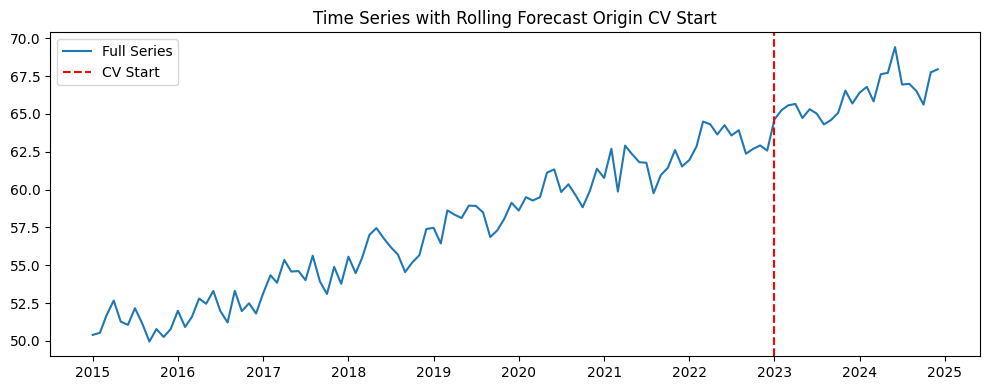

In [63]:
# 5) Plot series and CV start
fig = plt.figure(figsize=(10,4))
plt.plot(series, label="Full Series")
plt.axvline(series.index[T0], color="red", linestyle="--", label="CV Start")
plt.title("Time Series with Rolling Forecast Origin CV Start")
plt.legend(); plt.tight_layout()


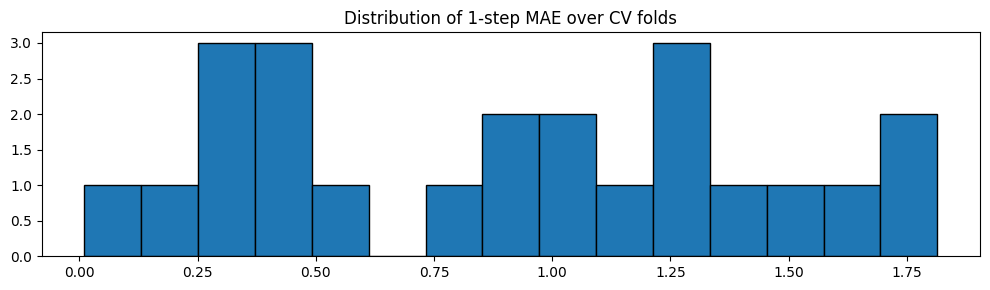

In [64]:
# 6) Error distribution plot
fig = plt.figure(figsize=(10,3))
plt.hist(errors_mae, bins=15, edgecolor="black")
plt.title("Distribution of 1-step MAE over CV folds")
plt.tight_layout()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on evaluating a forecasting model using rolling forecast origin cross-validation. The process began by creating a synthetic time series with trend, seasonality, and noise, and then visualizing it to understand its overall structure. After that, a rolling window approach was used where the model was trained on an expanding portion of the data and tested on the next single time step repeatedly. At each step, Holt’s Linear Trend model was fitted and used to make one-step-ahead predictions. The prediction errors were collected and used to calculate average MAE and RMSE across all folds. This helped provide a more reliable evaluation compared to a single train-test split. Overall, the exercise showed how cross-validation gives a better understanding of model performance over time and helps ensure the forecasting model is stable and consistent.


#### **Exercise 14: Applying Forecasting Models to a Real-World Case Study**

**Objective:**  
Apply and evaluate two practical forecasting baselines on a real monthly dataset. You will (1) load and prepare the data, (2) create a train/test split, (3) fit **Seasonal Naïve (s=12)** and **Holt–Winters (additive trend + additive seasonality)**, and (4) compare forecasts using **MAE, RMSE, MAPE**.

**Dataset (online):**  
**AirPassengers** (monthly) loaded from a public CSV. It has a clear yearly seasonality and long‑term growth.

**What you will do:**  
- Load the dataset and ensure a proper monthly DatetimeIndex.  
- Hold out the **last 12 months** as the test set.  
- Fit **Seasonal Naïve (s=12)** and **Holt–Winters (add, add, 12)** to the training data.  
- Forecast 12 months ahead and compute **MAE, RMSE, MAPE**.  
- Plot forecasts vs actuals and interpret which model performs better and why.

---

In [65]:
# Exercise 14 — Real-World Monthly Forecasting (Online-only)
# Dataset: AirPassengers (monthly) from public GitHub CSV
# Models: Seasonal Naive, Holt–Winters (add, add, 12)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from math import sqrt

np.random.seed(0)
plt.close('all')

# -----------------------------
# 1) Load monthly dataset (AirPassengers) from online CSV
# -----------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
series = df['Passengers'].astype(float).asfreq('MS')
series.name = 'value'

# -----------------------------
# 2) Train/Test split (last 12 months as test)
# -----------------------------
H = 12
train = series.iloc[:-H]
test  = series.iloc[-H:]


In [66]:
# -----------------------------
# 3) Helper: Seasonal Naive forecast (s=12)
# -----------------------------
def seasonal_naive_forecast(train_series, horizon, season=12):
    last_season = train_series.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    fc = np.tile(last_season, reps)[:horizon]
    idx = pd.date_range(train_series.index[-1] + pd.offsets.MonthBegin(),
                        periods=horizon, freq='MS')
    return pd.Series(fc, index=idx, name='SNaive')

# -----------------------------
# 4) Fit models
# -----------------------------
# A) Seasonal Naive (baseline)
sn_fc = seasonal_naive_forecast(train, H, season=12)

# B) Holt–Winters (additive trend + additive seasonality, s=12)
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12,
                                initialization_method='estimated')
hw_fit = hw_model.fit(optimized=True)
hw_fc  = hw_fit.forecast(H)


In [67]:
# -----------------------------
# 5) Metrics
# -----------------------------
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-8
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(eps, np.abs(y_true)))) * 100)

results = pd.DataFrame({
    "Model": ["Seasonal-Naive (s=12)", "Holt–Winters (add,add,12)"],
    "MAE":   [mae(test.values, sn_fc.values), mae(test.values, hw_fc.values)],
    "RMSE":  [rmse(test.values, sn_fc.values), rmse(test.values, hw_fc.values)],
    "MAPE (%)": [mape(test.values, sn_fc.values), mape(test.values, hw_fc.values)]
}).set_index("Model").sort_values("RMSE")

print("\nForecast Accuracy (lower is better):")
print(results)



Forecast Accuracy (lower is better):
                                 MAE       RMSE  MAPE (%)
Model                                                    
Holt–Winters (add,add,12)  13.382162  16.981068  2.803136
Seasonal-Naive (s=12)      47.833333  50.708316  9.987533


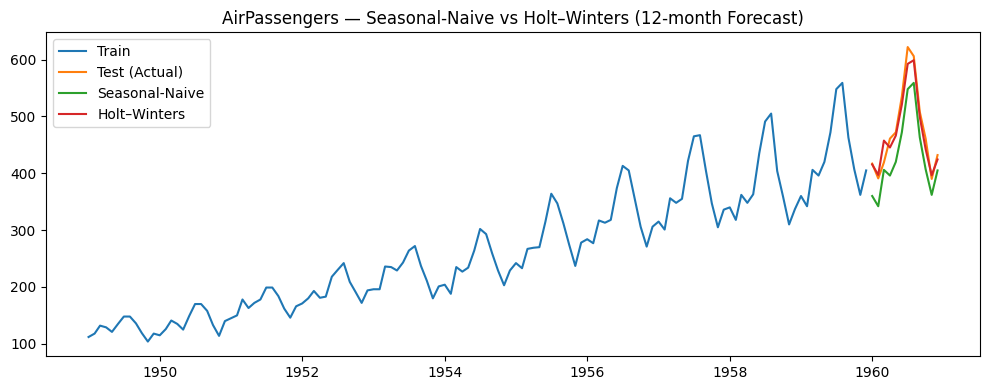

In [68]:
# -----------------------------
# 6) Plot forecasts vs actuals
# -----------------------------
fig = plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index,  test.values,  label="Test (Actual)")
plt.plot(test.index,  sn_fc.values, label="Seasonal-Naive")
plt.plot(test.index,  hw_fc.values, label="Holt–Winters")
plt.title("AirPassengers — Seasonal-Naive vs Holt–Winters (12-month Forecast)")
plt.legend(); plt.tight_layout()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on applying forecasting models to a real-world dataset and comparing their performance. The data was first loaded from an online source and converted into a proper monthly time series format. Then, the dataset was split into training and testing sets, with the last 12 months used for evaluation. Two forecasting methods were applied: Seasonal Naïve and Holt–Winters with additive trend and seasonality. Both models were used to predict future values, and their results were compared with the actual test data. Accuracy was measured using MAE, RMSE, and MAPE, which showed that Holt–Winters performed significantly better than the Seasonal Naïve approach. Overall, the exercise demonstrated how incorporating trend and seasonality into a model leads to more accurate and reliable forecasts in real-world time series data.


#### **Revised: September 1, 2025**